# **Project Name**    - Regression Model for Yes Bank Stock Price Prediction



##### **Project Type**    - Regression Model
##### **Contribution**    - Individual - Jevin Chokshi

# **Project Summary -**

**Project Overview**

This project focused on **developing and optimizing machine learning models** to predict **Yes Bank’s monthly closing stock prices**, leveraging historical financial and market data.  
The primary objective was to design **reliable regression models** capable of effectively explaining and forecasting price movements — supporting **strategic financial planning** and **risk management**.

---

**Models Implemented and Evaluated**

- **Linear Regression:**  
  Served as the baseline statistical model, offering strong initial performance with clear interpretability.

- **Random Forest Regressor:**  
  A robust ensemble algorithm designed to capture non-linear dependencies. However, in this dataset, hyperparameter tuning did not result in significant improvements over the baseline.

- **XGBoost Regressor:**  
  An advanced gradient boosting model that delivered the **highest predictive accuracy** and **consistent generalization** after fine-tuning through **GridSearchCV**.

---

**Performance Evaluation Metrics**

Model performance was rigorously assessed using metrics directly aligned with business forecasting objectives:

- **R² Score:** Measures the proportion of variance in stock prices explained by the model.  
- **Root Mean Squared Error (RMSE):** Evaluates the average magnitude of squared prediction errors.  
- **Mean Absolute Error (MAE):** Reflects the average absolute deviation from actual values.

---

**Validation and Robustness**

- **Cross-Validation:**  
  A 5-Fold **K-Fold Cross-Validation** approach ensured that each model was tested across multiple data partitions, reducing bias and preventing overfitting.

- **Learning Curve Analysis:**  
  Demonstrated that the **XGBoost model** maintained **low bias and variance**, confirming its stability and scalability with increasing data volume.

---

**Model Explainability**

The **feature importance analysis** from XGBoost provided insight into the most influential predictors impacting stock price movement.  
This interpretability strengthens the model’s business relevance, enabling **data-driven insights** for **investment decisions** and **strategic planning**.


# **Problem Statement**


The financial market is inherently volatile, making accurate stock price prediction both challenging and essential for investors and financial institutions.
  
For **Yes Bank**, reliable forecasting of monthly closing stock prices is vital to support **strategic investment decisions**, **risk management**, and **financial planning**.

This project focuses on developing a **machine learning regression model** capable of accurately predicting Yes Bank’s monthly closing prices using **historical trading data** and **market indicators**.  
Advanced algorithms such as **XGBoost**, combined with **hyperparameter tuning** and **cross-validation**, are employed to enhance **prediction accuracy** and **generalization performance**.

The key challenges addressed include:
- Selecting meaningful features from complex financial data.  
- Optimizing model parameters to minimize prediction errors.  
- Ensuring robustness across varying market conditions.  
- Maintaining interpretability through feature importance analysis.

The outcome is a **data-driven, reliable, and explainable forecasting model** that enables Yes Bank and its stakeholders to make **confident and informed financial decisions** aligned with market realities.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import scipy.stats as stats
from matplotlib.collections import LineCollection
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from google.colab import drive

### Dataset Loading

In [ ]:
# Load Dataset
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
bank_df = pd.read_csv(r"/content/drive/MyDrive/Resume Projects/data_YesBank_StockPrices.csv")

### Dataset First View

In [ ]:
# Dataset First
print(f"First 5 rows of the dataset: \n\n{bank_df.head()}")

First 5 rows of the dataset: 

     Date   Open   High    Low  Close
0  Jul-05  13.00  14.00  11.25  12.46
1  Aug-05  12.58  14.88  12.55  13.42
2  Sep-05  13.48  14.87  12.27  13.30
3  Oct-05  13.20  14.47  12.40  12.99
4  Nov-05  13.35  13.88  12.88  13.41


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"Number of rows in the dataset: {bank_df.shape[0]}\nNumber of columns in the dataset: {bank_df.shape[1]}.")

Number of rows in the dataset: 185
Number of columns in the dataset: 5.


### Dataset Information

In [ ]:
# Dataset Info
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print(f"Number of duplicate values in the dataset: {bank_df.duplicated().sum()}")

Number of duplicate values in the dataset: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print(f"Number of missing values in the dataset: {bank_df.isnull().sum().sum()}")

Number of missing values in the dataset: 0


<Axes: >

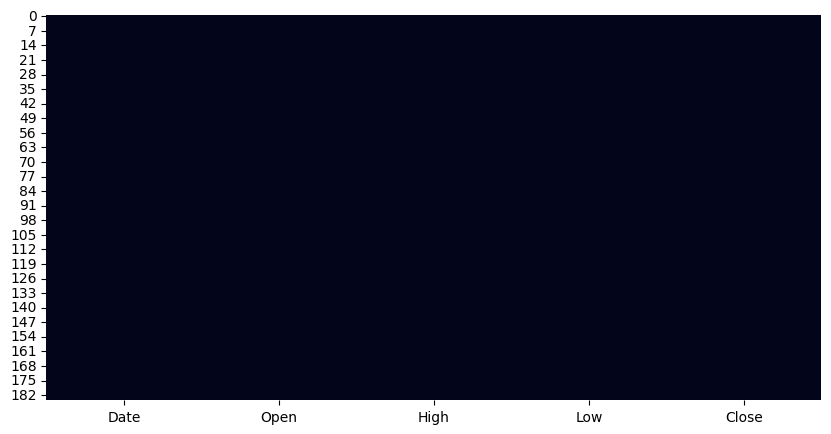

In [ ]:
# Visualizing the missing values
missing_values=bank_df.isnull()
plt.figure(figsize=(10, 5))
sns.heatmap(missing_values, cbar=False)

### What did you know about your dataset?

The dataset contains monthly stock price information for Yes Bank, including the opening, closing, highest, and lowest prices for each month. It is well-structured and free from missing or duplicate values, comprising a total of 185 records across five columns.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
print(f"The columns of the dataset are: \n\n{bank_df.columns}")

The columns of the dataset are: 

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')


In [ ]:
# Dataset Describe
print(f"Statisticat Summary of the Dataset: \n\n{bank_df.describe(include='all')}")


Statisticat Summary of the Dataset: 

          Date        Open        High         Low       Close
count      185  185.000000  185.000000  185.000000  185.000000
unique     185         NaN         NaN         NaN         NaN
top     Jul-05         NaN         NaN         NaN         NaN
freq         1         NaN         NaN         NaN         NaN
mean       NaN  105.541405  116.104324   94.947838  105.204703
std        NaN   98.879850  106.333497   91.219415   98.583153
min        NaN   10.000000   11.240000    5.550000    9.980000
25%        NaN   33.800000   36.140000   28.510000   33.450000
50%        NaN   62.980000   72.550000   58.000000   62.540000
75%        NaN  153.000000  169.190000  138.350000  153.300000
max        NaN  369.950000  404.000000  345.500000  367.900000


### Variables Description

**Date**: The date on which the stock price data was recorded.

**Open**: The opening price of the stock at the beginning of the period.

**High**: The highest price the stock reached during the period.

**Low**: The lowest price the stock reached during the period.

**Close**: The closing price of the stock at the end of the period.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
print(f"Number of unique values in each column are: \n\n{bank_df.nunique()}")

Number of unique values in each column are: 

Date     185
Open     183
High     184
Low      183
Close    185
dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
df = bank_df.copy()
# Convert Date strings to datetime values:
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df.sort_values(by='Date', ascending=False)

#Get Month, Quarter and Year:
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Year'] = df['Date'].dt.year

#Get price movement and returns:
df['Price_change'] = df['High'] - df['Low']
df['Returns'] = df['Close'] - df['Open']

In [ ]:
# Helper Function 1: Retrive a dependent column value
def dependent_column_value(df, val_col, val, fil_col):
  """
  Returns the Corresponding value in the column 'fil_col'
  where df[val_col] == val.

  If no match is found or the columns are missing, it return N/A"""

  try:
    if val_col not in df.columns or fil_col not in df.columns:
      raise KeyError(f"One of the columns '{val_col}' or '{fil_col}' is missing.")

    filtered = df[df[val_col] == val]
    if filtered.empty:
      return 'N/A'
    return filtered[fil_col].values[0]
  except Exception as e:
    print(f"Error Retriving Dependent Values: {e}")
    return 'N/A'

# Helper Function 2: Print min/max stats for any column:
def print_stat(df, col, label, month_col='Month', year_col='Year'):
  """
  Print Highest and Lowest values of a Price column along with their
  corresponding month and year.
  """
  try:
    if col not in df.columns:
      raise KeyError(f"Column '{col}' is missing.")

    highest = df[col].max()
    lowest = df[col].min()

    print(f"Highest {label} of Rs. {round(highest, 2)} was recorded in month: {dependent_column_value(df, col, highest, month_col)} year: {dependent_column_value(df, col, highest, year_col)}.\n")
    print(f"Lowest {label} of Rs. {round(lowest, 2)} was recorded in month: {dependent_column_value(df, col, lowest, month_col)} year: {dependent_column_value(df, col, lowest, year_col)}.\n")

  except Exception as e:
    print(f"Error in printing stats for {label}: {e}.")

#Helper Function 3: Print min/max stat based on a grouped column:
def print_grouped_stat(df, group_col, value_col, label):
  """Groups the data based on the group_col and prints:
  - Highest and Lowest values of Positive/Negative a Price column.
  - Lowest Positive and Highest Negative value of a Price column.
  """

  try:
    #Group the data based on group col
    grouped = df.groupby(group_col)[value_col].sum().reset_index()
    # Get the maximum and minimum values of Price col
    max_val = grouped[value_col].max()
    min_val = grouped[value_col].min()
    # Print the results using dependent_column_value function
    print(f"Highest {label} of Rs. {round(max_val, 2)} was recorded in {" ".join(f"{col}: {dependent_column_value(grouped, value_col, max_val, col)}"for col in group_col)}.\n")
    print(f"Lowest {label} of Rs. {round(min_val, 2)} was recorded in {" ".join(f"{col}: {dependent_column_value(grouped, value_col, min_value, col)}" for col in group_col)}.")

    # Get all positive and negative values of Price col:
    positive_values = grouped[grouped[value_col] > 0]
    negative_values = grouped[grouped[value_col] < 0]

    lowest_positive = positive_values[value_col].min()
    highest_negative = negative_values[value_col].max()

    print(f"Lowest Profit of Rs. {round(lowest_positive, 2)} was recorded in {" ".join(f"{col}: {dependent_column_value(positive_values, value_col, lowest_positive, col)} for col in group_col")}.\n")
    print(f"Lowest Loss of Rs. {round(highest_negative, 2)} was recorded in {" ".join(f"{col}: {dependent_column_value(negative_values, value_col, highest_negative, col)} for col in group_col")}.")
  except Exception as e:
    print(f"Error in printing grouped stats for {label}: {e}")

# Main Fuction to Print the Price Information:
def analyze_df(df):
  """
  Prints all the Price Information for a Stock Price
  Dataframe:
  - Highest and Lowest Prices.
  - Highest and Lowest Price Changes.
  - Highest and Lowest Profits/Losses Monthly, Quarterly and Yearly.
  """

  print("---PRICE ANALYSIS---\n\n")
  print_stat(df, 'High', "Returns")
  print_stat(df, 'Low', "Returns")

  print("\n\n---PRICE CHANGE ANALYSIS---\n\n")
  print_stat(df, 'Price_change', "Price Change")

  print("\n\n---MONTHLY PROFIT/LOSS ANALYSIS---\n\n")
  print_stat(df, 'Returns', "Monthly Returns")

  print("\n\n---QUARTERLY PROFIT/LOSS ANALYSIS---\n\n")
  print_grouped_stat(df, ['Year', 'Quarter'], 'Returns', "Quarterly Returns")

  print("\n\n--YEARLY PROFIT/LOSS ANALYSIS---\n\n")
  print_grouped_stat(df, ['Year'], 'Returns', "Yearly Returns")

In [ ]:
analyze_df(df)

---PRICE ANALYSIS---


Highest Returns of Rs. 404.0 was recorded in month: 8 year: 2018.

Lowest Returns of Rs. 11.24 was recorded in month: 3 year: 2009.

Highest Returns of Rs. 345.5 was recorded in month: 9 year: 2017.

Lowest Returns of Rs. 5.55 was recorded in month: 3 year: 2020.



---PRICE CHANGE ANALYSIS---


Highest Price Change of Rs. 183.85 was recorded in month: 9 year: 2018.

Lowest Price Change of Rs. 1.0 was recorded in month: 11 year: 2005.



---MONTHLY PROFIT/LOSS ANALYSIS---


Highest Monthly Returns of Rs. 68.92 was recorded in month: 7 year: 2017.

Lowest Monthly Returns of Rs. -163.75 was recorded in month: 9 year: 2018.



---QUARTERLY PROFIT/LOSS ANALYSIS---


Highest Quarterly Returns of Rs. 86.1 was recorded in Year: 2019 Quarter: 1.

Error in printing grouped stats for Quarterly Returns: name 'min_value' is not defined


--YEARLY PROFIT/LOSS ANALYSIS---


Highest Yearly Returns of Rs. 77.81 was recorded in Year: 2014.

Error in printing grouped stats for Yea

### What all manipulations have you done and insights you found?

### Data Preparation and Transformation

To make the dataset ready for detailed analysis, several preprocessing steps were performed:

- A **duplicate copy** of the dataset was created to preserve the original data.
- The **Date** column (e.g., "Jan-20") was converted into a proper datetime object for accurate time-based analysis.
- The data was **sorted chronologically** to maintain consistency.
- Additional time-based columns — **Month**, **Year**, and **Quarter** — were extracted for analysis at multiple scales (monthly, quarterly, yearly).

Two new calculated columns were added:
- **Price_change** = High − Low → shows price volatility during each period.  
- **Gains** = Close − Open → shows net profit or loss during that period.

Custom helper functions were also defined to:
- Retrieve **month or year names** for key numeric values.
- Identify and print **highest** and **lowest** values for prices, volatility, and gains.
- **Group data** by quarter and year to calculate aggregated gains and losses.

Overall, these transformations turned the raw dataset into a **structured, analysis-ready format**, enabling multi-level performance evaluation.

---

#### Key Insights and Outcomes

### 1. Price Analysis
- The **highest recorded price** marks the period of maximum market strength or investor confidence.  
- The **lowest price** represents the weakest phase, possibly reflecting reduced demand or external pressure.  
- Together, these extremes define how much the asset’s value fluctuated over time.

**Outcome:**  
The analysis identified the **exact months and years** when prices reached their highest and lowest points — highlighting the market’s best and worst valuation periods.

---

### 2. Price Change (Volatility)
- The **Price_change** metric (High − Low) captured periods of sharp movement or stability.  
- **Large differences** indicate high volatility — often due to major events or market reactions.  
- **Small differences** show calmer market conditions.

**Outcome:**  
The code detected the **most volatile month**, where price swings were the greatest, and the **most stable month**, where variation was minimal.

---

### 3. Monthly Gains and Losses
- **Monthly gains** (Close − Open) show overall performance per month.  
- The **highest monthly gain** reflected strong upward momentum.  
- The **largest monthly loss** indicated a major correction or market drop.  
- The **smallest gain/loss** pointed to months of moderate performance.

**Outcome:**  
The analysis pinpointed **specific months and years** with the **maximum profit** and **largest loss**, offering insight into short-term market behavior.

---

### 4. Quarterly Gains and Losses
- Aggregating by **quarter** provided a broader picture of performance trends.  
- The **best-performing quarter** represented sustained recovery or growth.  
- The **worst quarter** indicated a period of consistent losses.  
- The **lowest positive** and **smallest negative** quarters highlighted mild fluctuations.

**Outcome:**  
The analysis summarized the **strongest and weakest quarters**, showing when the market sustained growth or experienced decline.

---

### 5. Yearly Gains and Losses
- Yearly aggregation revealed long-term profitability patterns.  
- The **best-performing year** showed consistent positive momentum.  
- The **worst-performing year** marked significant losses, possibly due to broader market factors.  
- Fluctuating yearly results indicated cyclical market behavior.

**Outcome:**  
The analysis identified **years with the highest and lowest total gains**, summarizing long-term performance across the dataset.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

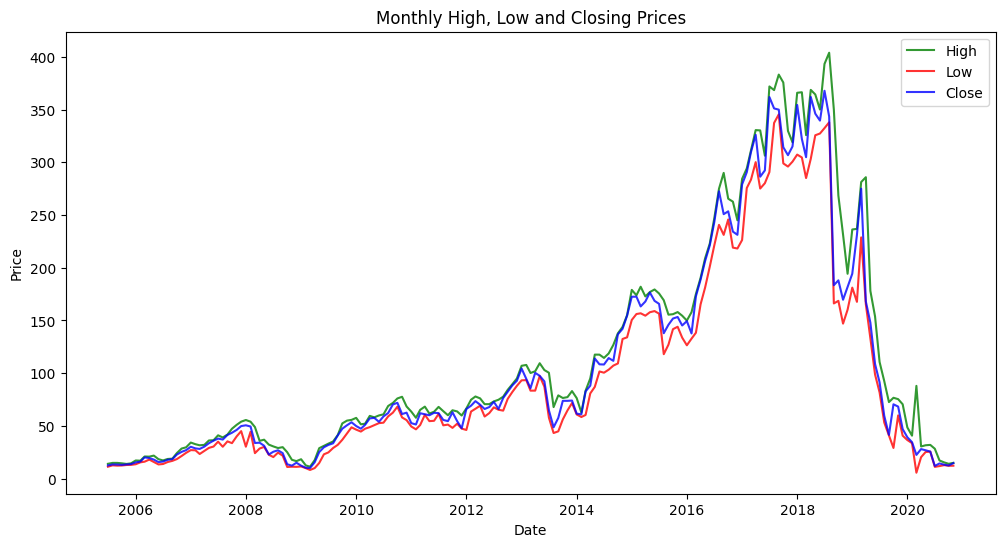

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['High'], label='High', alpha=0.8, color='green')
plt.plot(df['Date'], df['Low'], label='Low', alpha=0.8, color='red')
plt.plot(df['Date'], df['Close'], label='Close', alpha=0.8, color='blue')
plt.title('Monthly High, Low and Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

Line charts excel at displaying continuous time-series data, making them ideal for tracking price movements across months and years. The chart simultaneously displays three related metrics (High, Low, and Close prices) using different colored lines allowing multiple value comparision. Line charts naturally emphasize trends, slopes, and directional changes.

##### 2. What is/are the insight(s) found from the chart?

- **The Dramatic Collapse (2018–2020):**  
  The most striking insight is the catastrophic decline from a peak of approximately **₹400** in August 2018 to below **₹20** by March 2020 — a loss exceeding **95%** of the bank's market value.  
  This coincides precisely with the timeline of **Rana Kapoor's governance failures**, rising **NPAs**, and eventual **fraud allegations**.

- **Pre-Crisis Growth Phase (2005–2018):**  
  The chart shows sustained growth from inception around **₹15–20** in 2006 to the **₹400 peak** in 2018, representing a massive appreciation driven by **aggressive lending practices** and **market optimism** before the underlying asset quality issues surfaced.

- **Peak Volatility Period (2018–2020):**  
  The significant gap between high and low prices during **2018–2019** reveals extreme **market uncertainty**.  
  Monthly price ranges widened dramatically as negative news emerged — **RBI restrictions on Rana Kapoor's tenure (January 2019)**, **UBS reports on rising NPAs**, and **deteriorating financial metrics** caused wild swings as investors **panic-sold**.

- **The RBI Moratorium Impact (March 2020):**  
  The sharp vertical drop in March 2020 corresponds to the **RBI imposing a moratorium on Yes Bank**, superseding the board, and **limiting withdrawals to ₹50,000**.  
  The stock crashed to an intraday low of **₹5.55** before closing at **₹16.80**, down **55% in a single day**.

- **Limited Recovery Post-Crisis (2020–2025):**  
  Following the crisis, the stock has stabilized in the **₹20–30** range but has never recovered significantly.  
  Despite **restructuring efforts** led by **SBI and HDFC**, improved **NPA metrics (1.6% gross NPA by June 2025)**, and recent **profit surges**, the stock remains **95% below its 2018 peak**, indicating **sustained loss of investor confidence**.

- **Black Swan Event Characteristics:**  
  The chart perfectly illustrates a **“black swan event”** in financial markets — an unpredictable, rare occurrence with **catastrophic consequences**.  
  The **fraud case** and subsequent **collapse** weren’t anticipated by traditional market analysis, as evidenced by the stock’s **strong performance right up until the crisis began**.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Insights (Dominant)

- **Predictive Model Limitations During Crises:**  
  The chart starkly demonstrates the fundamental limitation of **time series** and **machine learning models** when faced with unprecedented crisis events.  
  Traditional predictive models rely on historical patterns, but the **Yes Bank collapse** was driven by **hidden fraud**, **regulatory intervention**, and **governance failures** — factors not captured in historical price data.  
  Any model trained on pre-2018 data would have been **blindsided by the 95% crash**, as these events fall outside the realm of normal market behavior.

- **Risk Management Failure Indicator:**  
  The gradual increase followed by sudden collapse reveals a classic pattern of **hidden systemic risk**.  
  Between **April–June 2018**, Yes Bank invested **₹3,700 crore** in DHFL debentures while DHFL provided **₹600 crore** in kickbacks to Kapoor's family entities — transactions that inflated the bank's balance sheet while concealing **toxic assets**.  
  The chart shows **market participants failed to detect these warning signs** until it was too late.

- **Investor Wealth Destruction:**  
  The visualization quantifies **catastrophic wealth destruction**.  
  Investors who bought at the **₹400 peak** lost approximately **95% of their investment**, with depositors facing withdrawal restrictions of just **₹50,000** during the moratorium.  
  This has lasting implications for **trust in private banking stocks** and creates **reputational damage** that persists.

- **Model Overfitting Dangers:**  
  The pre-crisis growth trend could easily lead to **overfitting** in predictive models.  
  A model trained on **2005–2017 data** would learn **aggressive growth patterns** and miss the underlying deterioration in asset quality.

- **Black Swan Unpredictability:**  
  Research confirms that **machine learning models struggle with “black swan events”** — rare, high-impact occurrences like **fraud-induced bank collapses**.  
  The **Yes Bank case** epitomizes this challenge: the fraud was **unprecedented**, regulatory intervention was **sudden**, and the magnitude of impact was **outside typical statistical distributions**.  
  Models based on normal market conditions provide a **false sense of security**.


---

Positive Growth Insights (Limited but Important)

- **Early Warning Signal Detection:**  
  While the crash itself was unpredictable, the chart does reveal some **early warning signals** between **2018–2019**.  
  The increased **volatility** (widening gaps between high and low) and the initiation of **downward trends** could have served as **risk indicators** for sophisticated anomaly detection systems.  
  This suggests that combining **traditional time series models** with **real-time anomaly detection algorithms** might help identify periods of **elevated risk**.

- **Recovery Pattern for Restructuring Analysis:**  
  The post-2020 stabilization phase (**₹20–30 range**) provides valuable data for modeling **post-crisis recovery dynamics**.  
  This could inform **risk management strategies** for other distressed financial institutions, showing that even after catastrophic failures,  
  **coordinated regulatory intervention** (RBI-led restructuring with **SBI/HDFC infusion**) can prevent **complete collapse**.

- **Volatility as a Predictor:**  
  The extreme **volatility during 2018–2019** (before the ultimate collapse) validates research showing that **volatility itself** can be a **better predictor** than raw price movements during crisis periods.  
  Models incorporating **volatility measures** (like VIX for market indices) or calculating **rolling standard deviations** might have signaled **heightened risk earlier** than price-based predictions.

- **Feature Engineering Opportunities:**  
  For **machine learning practitioners**, this chart informs **feature creation strategies**.  
  Incorporating **external variables** beyond price data — such as **NPA ratios**, **provision coverage ratios**, **credit-deposit ratios**, **regulatory actions**, and **news sentiment** — becomes critical for **crisis prediction models**.  
  The Yes Bank case proves that **price data alone is insufficient**.


#### Chart - 2



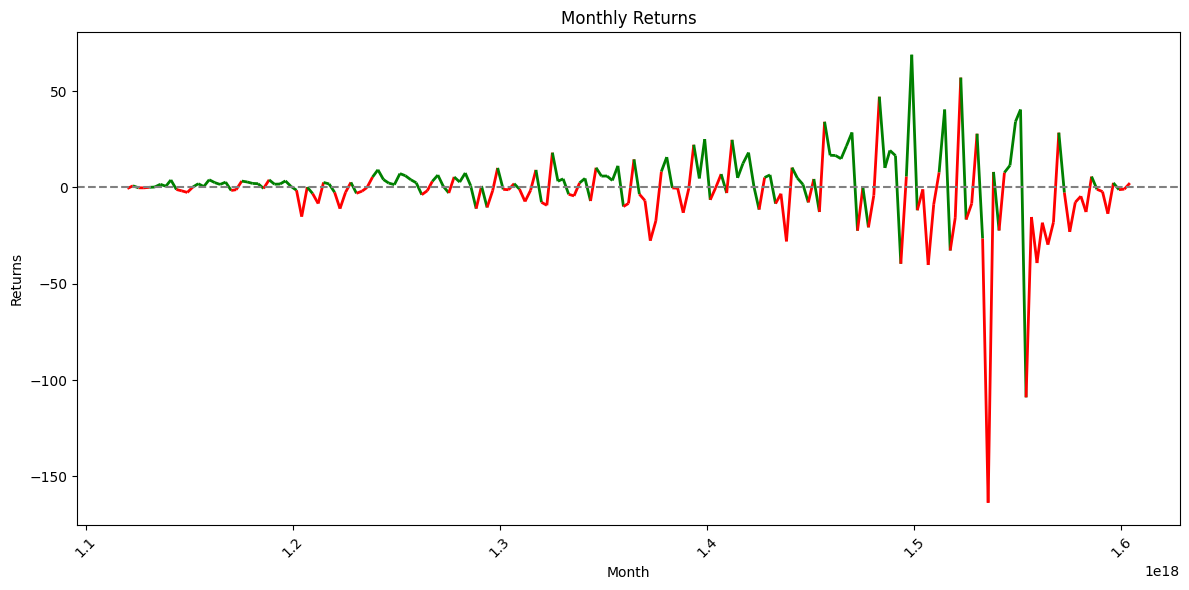

In [ ]:
# Chart - 2 visualization code
x = df['Date'].values
y = df['Returns'].values

# Prepare segments
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Assign color for each segment
colors = ['green' if y[i] >= 0 else 'red' for i in range(len(y) - 1)]

lc = LineCollection(segments, colors=colors, linewidth=2)
fig, ax = plt.subplots(figsize=(12, 6))
ax.add_collection(lc)
ax.autoscale()
ax.axhline(0, color='gray', linestyle='--')
plt.title('Monthly Returns')
plt.xlabel('Month')
plt.ylabel('Returns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The selected chart is a line chart showing monthly returns. Plotting monthly percentage returns rather than absolute prices, the chart provides a clearer picture of the volatility, frequency, and magnitude of gains and losses over time. The use of color coding helps quickly distinguish between periods of recovery (green) and drawdowns (red).

##### 2. What is/are the insight(s) found from the chart?

- **Pre-2018: Stable to Moderate Volatility**  
  Prior to 2018, returns remained largely stable with limited fluctuations. This period reflects a relatively steady performance characterised by modest gains and controlled volatility.

- **Post-2018: Elevated Volatility and Significant Decline**  
  From 2018 onwards, the data indicates a sharp rise in volatility accompanied by several steep negative returns.  
  These extreme downturns align with the period of financial irregularities and the subsequent regulatory actions that adversely affected Yes Bank’s market performance.  
  The most severe declines — where returns dropped below **-100% in a single month** — capture the market’s reaction to the unfolding crisis and erosion of investor confidence.

- **Short-Lived Positive Movements**  
  Occasional positive spikes (green bars) are observed, suggesting brief recovery attempts.  
  However, these upswings were unsustainable and were quickly followed by renewed losses, indicating transient optimism overshadowed by persistent market concerns.

- **Prolonged Negative Phase**  
  The extended series of negative returns (red bars) during and after the crisis highlights a sustained phase of weak sentiment and diminished investor trust.  
  This reflects not only isolated adverse events but a **prolonged loss of market confidence** in the institution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Severe Wealth Erosion**  
  Periods of extreme negative returns align closely with phases of regulatory intervention, fraud exposure, and major NPA disclosures.  
  The sequence of sharp consecutive declines clearly illustrates how catastrophic events can rapidly erode investor wealth, leading to a prolonged loss of confidence in the institution.

- **Modelling Challenges During Crises**  
  These extreme negative movements represent “outlier” or “black swan” events.  
  Traditional time series and predictive models—trained on historical return patterns—struggle to anticipate such rare and high-impact occurrences, as their magnitude and frequency lie outside typical volatility ranges.  
  The data underscores the need for more advanced modelling approaches, such as **regime-switching frameworks**, **robust volatility models**, and the incorporation of **external signals** like news sentiment or governance risk indicators, to enhance predictive accuracy and risk management.

- **Persistent Risk Aversion**  
  The sustained presence of negative returns (red bars) post-2018 indicates a continued erosion of market confidence.  
  This prolonged scepticism adversely affects the bank’s reputation, its capital-raising capability, and overall business outlook, resulting in **long-term negative financial implications**.

---

Positive Business Insights (Limited)

- **Volatility as an Early Warning Indicator**  
  The heightened volatility and increased frequency of negative months could serve as a potential **early warning signal** for investors and risk managers.  
  Recognising and acting on these signals proactively could have helped mitigate losses or prompted deeper due diligence before the most severe downturn occurred.

- **Strengthening Stress Testing Frameworks**  
  Insights derived from this analysis can encourage organisations to **enhance stress testing** and **scenario planning** practices.  
  Incorporating extreme market conditions into model assumptions can significantly improve preparedness for future unforeseen crises and strengthen overall financial resilience.


#### Chart - 3

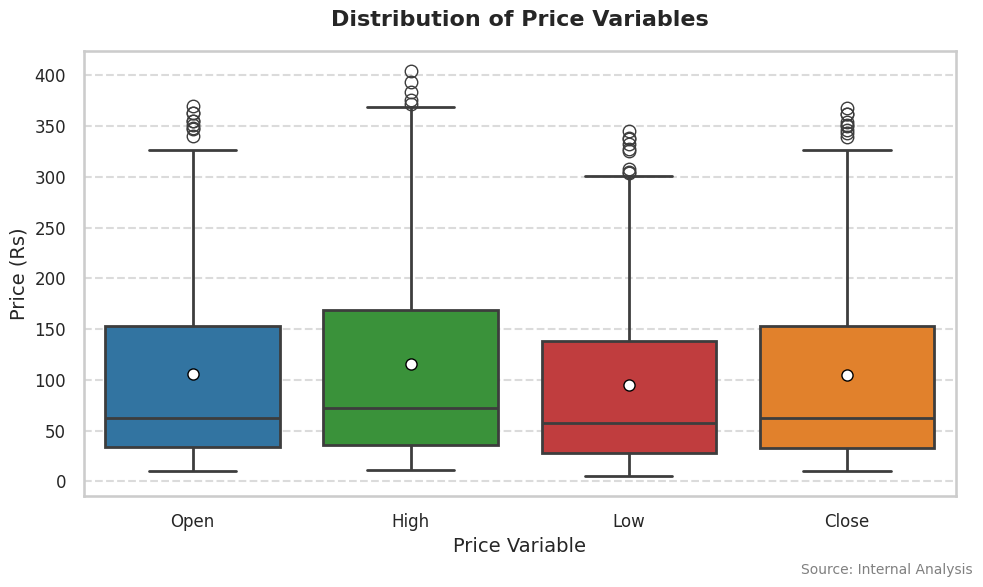

In [ ]:
# Chart - 3 visualization code
## Boxplot – Price Variables
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.set_context("talk")

# Professional color palette
palette = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e"]

# Plot with improved look
ax = sns.boxplot(
    data=df[['Open', 'High', 'Low', 'Close']],
    palette=palette,
    linewidth=2,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

plt.title("Distribution of Price Variables", fontsize=16, fontweight='semibold', pad=18)
plt.ylabel("Price (Rs)", fontsize=14)
plt.xlabel("Price Variable", fontsize=14)
plt.xticks(fontsize=12, fontweight='medium')
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add footnote or source
plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot chart is the most effective visualization for understanding the distribution of monthly price variables. Placing boxplots for all four price variables on the same axis, one can quickly compare their distributions, spotting differences in volatility and value ranges, and investigating any pattern between Open, High, Low, and Close.

##### 2. What is/are the insight(s) found from the chart?

- **Strong Positive Skew and Outliers**  
  All price variables exhibit a **positive skew**, characterised by long upper whiskers and a dense cluster of outliers at the higher end.  
  This pattern reflects the **boom phase leading up to 2018**, marked by sharp price appreciation and multiple spikes in the ₹350–₹400 range prior to the subsequent market correction.

- **Similar Spread Across Price Variables**  
  The **Open, High, Low, and Close** prices display a broad **interquartile range (IQR)**, highlighting the considerable volatility in Yes Bank’s monthly trading activity.  
  The relative position of the median (in the lower half of the box) and the mean (white marker) indicates a **downward bias in price movement** following the crisis period.

- **Extreme Volatility Patterns**  
  The large number of outliers—particularly on the higher end—illustrates **frequent abnormal price fluctuations**, consistent with both the pre-crisis rally and the turbulent period during and after the fraud revelations.  
  Such volatility underscores the heightened uncertainty and speculative trading behaviour during these phases.

- **Close and Open Price Distributions**  
  The **Close** and **Open** price distributions appear nearly identical, suggesting that **intra-month changes were relatively minor** compared to the overall trading range.  
  Notable deviations occurred only during months influenced by **extraordinary market developments or major news events**.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Outliers Indicate Market Instability**  
  The abundance of outliers and extended whiskers clearly indicate that Yes Bank’s stock experienced **highly unpredictable price movements**, particularly during the 2018 crisis period.  
  This elevated volatility not only increases investor risk but also complicates **financial forecasting and risk assessment**.

- **Non-Stationarity Challenges**  
  The **skewed distributions** and **sudden shifts in range and median** highlight the presence of **non-stationarity**—a fundamental challenge in time series forecasting.  
  Conventional predictive models often underperform under such conditions, especially during **regime shifts** or **external shocks**, necessitating the adoption of **advanced volatility models** or **change-point detection techniques**.

- **Potential for Wealth Erosion**  
  Investors who entered the market at the higher outlier levels faced **significant capital loss** as prices corrected to lower median values post-crisis.  
  This underscores the **negative impact on investor wealth**, alongside a **deterioration in institutional credibility and reputation**.

---

Positive Business Insights

- **Risk Control and Feature Selection**  
  The boxplot analysis provides valuable inputs for identifying **predictive variables** and **potential risk indicators**.  
  For instance, abrupt spikes in *High* prices or sudden dips in *Low* prices can serve as **early triggers** for implementing risk controls or anomaly detection mechanisms.

- **Data-Driven Decision Making**  
  Recognising patterns of **volatility and outlier behaviour** supports informed regulatory and managerial actions aimed at **risk mitigation**.  
  Such insights can drive improvements in **corporate governance**, **market communication**, and **risk disclosure practices**, ultimately strengthening institutional resilience.


#### Chart - 4

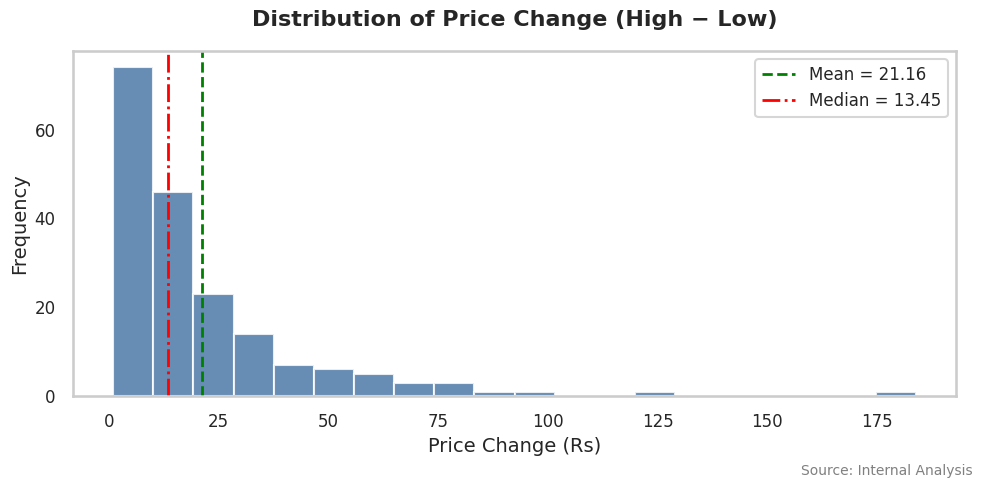

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
sns.set_context("talk")

# Plot with improved aesthetics
n, bins, patches = plt.hist(
    df['Price_change'],
    bins=20,
    color='#4e79a7',
    edgecolor='white',
    alpha=0.85,
    linewidth=1.5
)

# Add mean and median reference lines
mean_val = df['Price_change'].mean()
median_val = df['Price_change'].median()
plt.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, color='red', linestyle='-.', linewidth=2, label=f'Median = {median_val:.2f}')

# Titles and labels formatted for business context
plt.title("Distribution of Price Change (High − Low)", fontsize=16, fontweight='semibold', pad=18)
plt.xlabel("Price Change (Rs)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(False)
plt.legend(fontsize=12, frameon=True)
plt.tight_layout()

# Subtle source/footer text
plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the preferred method for examining the distribution of absolute price changes. This visualization is crucial for quantifying typical versus unusual levels of volatility—central for risk management and financial modeling. By overlaying mean and median lines, the chart provides immediate insight into central tendency and skewness.

##### 2. What is/are the insight(s) found from the chart?

- **Positive Skew with a Heavy Tail**  
  The distribution reveals a **strong positive skew**, with most months showing relatively small price movements clustered below ₹25.  
  However, a few months exhibit exceptionally large fluctuations, as reflected by the **long right tail extending up to nearly ₹180**, representing rare but high-impact market events.

- **Median vs. Mean Comparison**  
  The **median monthly price change (₹13.45)** is notably lower than the **mean (₹21.16)**, highlighting the influence of **extreme outlier months**.  
  These outliers inflate the overall average, suggesting that a typical month experiences far less volatility than the statistical mean implies.

- **Prevalence of Low Volatility Periods**  
  The majority of data points—spanning over **60 months**—are concentrated within the initial bins, confirming that **low to moderate volatility** was the norm for most of the observed period.  
  Episodes of erratic price behaviour were therefore **infrequent but significant** when they occurred.

- **Impact of Extreme Volatility Events**  
  The **extended tail of high price change values** likely corresponds to crisis periods, such as the **Rana Kapoor case** and subsequent **regulatory interventions**.  
  These instances represent **rare but severe disruptions** that had a lasting impact on investor sentiment and market stability.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Risk from Extreme Volatility:**  
  The presence of multiple months exhibiting significantly higher-than-average price ranges indicates heightened exposure to market shocks.  
  This makes **risk management** for both investors and the institution more challenging during periods of **stress or adverse news flow**.

- **Modeling Sensitivity:**  
  Predictive models developed on such datasets must be capable of managing **non-Gaussian and skewed distributions**.  
  Relying on assumptions of “normal” volatility tends to **underestimate the probability of large price fluctuations**, reducing model reliability during **high-impact or crisis situations**.

- **Unreliable Mean Volatility Measures:**  
  Dependence on mean values may **overstate typical market risk**, leading to **either excessive risk-taking or undue conservatism**, depending on the context of decision-making and portfolio objectives.


---

Positive Business Impact

- **Majority Months Exhibit Stability:**  
  The fact that the **median volatility** is significantly lower than the mean suggests that in most months, the market remains **relatively stable**.  
  This stability supports **operational planning**, **treasury management**, and **short-term risk assessment** for the bank and its stakeholders.

- **Crisis Period Identification:**  
  The histogram distinctly highlights **outlier months**, allowing leadership teams to **correlate these anomalies with specific events**.  
  This insight can guide **future governance frameworks**, **regulatory preparedness**, and **strategic interventions**.

- **Feature Engineering Insights:**  
  For **time series modelling** and **predictive analytics**, recognising the frequency and magnitude of volatility spikes enables data scientists to **design features that capture abrupt risk shifts** and to apply **robust models resilient to outliers**.


#### Chart - 5

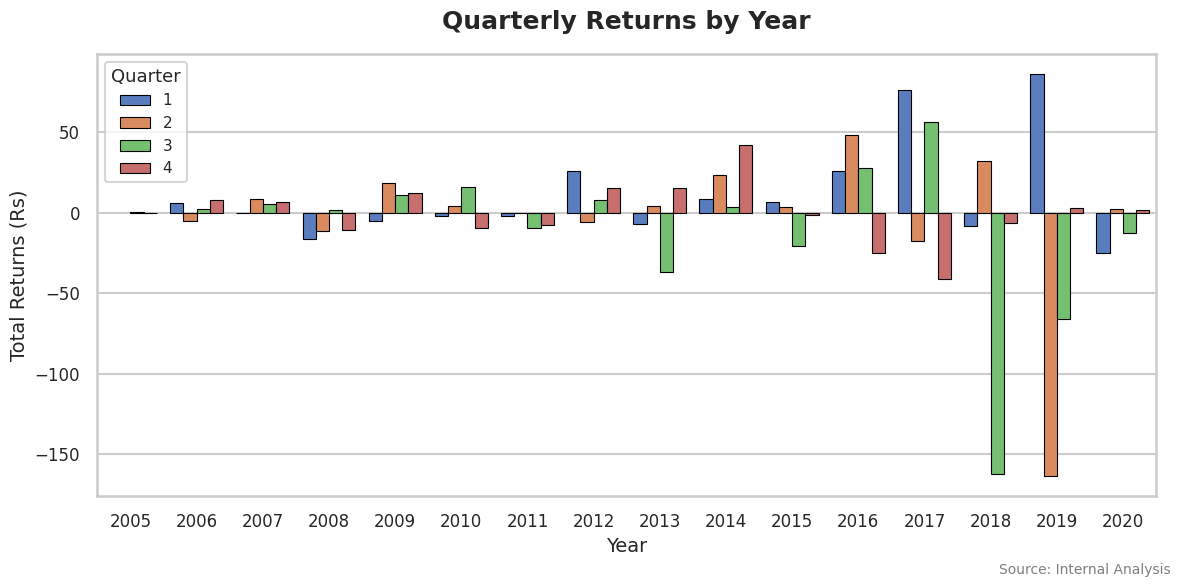

In [ ]:
# Chart - 5 visualization code
quarterly_gains = df.groupby(['Year', 'Quarter'])['Returns'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.set_context("talk")

# Use a professional color palette
palette = sns.color_palette("muted", n_colors=4)

ax = sns.barplot(x='Year', y='Returns', hue='Quarter', data=quarterly_gains, palette=palette, edgecolor='black', linewidth=0.8)

plt.title("Quarterly Returns by Year", fontsize=18, fontweight='semibold', pad=18)
plt.ylabel("Total Returns (Rs)", fontsize=14)
plt.xlabel("Year", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Quarter", title_fontsize=13, fontsize=11, loc='upper left', frameon=True)

plt.tight_layout()

# Source annotation
plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')

plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart is ideal for visualizing quarterly returns across multiple years. This format allows direct comparison of returns for each quarter within a year, highlighting seasonality, policy impact, or macroeconomic shifts. Enables to spot repeating patterns, abrupt regime shifts, or quarters that consistently underperform or outperform

##### 2. What is/are the insight(s) found from the chart?

- **Stable / Low Volatility Years (2005–2016):**  
  Most quarters up to 2016 exhibit **moderate and fluctuating returns**, with gains and losses distributed relatively evenly.  
  There are **no drastic outliers**, indicating a period of operational stability and consistent market performance.

- **Sharp Regime Shift in 2018–2019:**  
  The most striking observation is the **steep negative returns** recorded in **Q3 2018 and Q2 2019** (green and orange bars dropping below –150).  
  These quarters align directly with **Yes Bank’s crisis period**, following revelations of **fraud, governance lapses, and financial distress**.  
  The magnitude of these losses **far exceeds any prior fluctuations** in the series.

- **Isolated Positive Spikes (2016–2017):**  
  The years 2016 and 2017 display several **strong positive quarters** (bars above +50), reflecting **favourable market sentiment** and **robust operational performance** in the years immediately preceding the crisis.

- **Post-2018 Instability and Negative Trend:**  
  The pattern following 2018 reveals **recurrent quarterly losses**, underscoring **persistent instability** and the **absence of a sustained recovery phase**.  
  Notably, **no year post-crisis** has demonstrated uniformly positive quarters.

- **Quarter-Specific Risk Exposure:**  
  Certain quarters, particularly **Q2 and Q3**, appear **more susceptible to adverse movements**, as evidenced by sharper declines during the downturn years.  
  This indicates potential **calendar-based or event-driven vulnerability**, which should be factored into **risk forecasting and stress testing frameworks**.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Crisis Impact Quantified:**  
  The **extreme negative bars** observed in **2018 and 2019** clearly illustrate the magnitude of **value erosion** resulting from **governance lapses**, **regulatory intervention**, and **investor panic**.  
  This visual evidence highlights how pivotal events can **instantly wipe out years of shareholder value**, reinforcing the need for strong risk governance mechanisms.

- **Elevated Post-Crisis Risk:**  
  The persistence of **negative quarterly returns** post-crisis reflects **prolonged market distrust**, **restricted funding access**, and continued **business headwinds**.  
  This sustained instability underscores the challenges of rebuilding market confidence following a governance-driven crisis.

- **Forecasting Limitations:**  
  Predictive models trained solely on **pre-crisis data** would **severely underestimate the likelihood of downturns**, given their dependence on historical averages.  
  This demonstrates the **limitations of conventional forecasting approaches** and the necessity to incorporate **stress scenarios and structural break considerations**.


---

Positive Business Impact

- **Historical Benchmarking and Recovery Assessment:**  
  The **positive quarterly spikes** provide valuable **performance benchmarks**, illustrating achievable recovery levels during favourable periods.  
  These insights can support **target-setting**, **performance evaluation**, and **strategic planning** for future stabilization and growth initiatives.

- **Strategic Seasonality Management:**  
  Identifying quarters that consistently exhibit **underperformance** enables leadership teams and risk managers to **proactively prepare** through appropriate **hedging strategies**, **liquidity buffers**, and **stakeholder communication plans**.  
  This enhances the institution’s ability to **anticipate cyclical risks** and respond effectively to market volatility.


#### Chart - 6

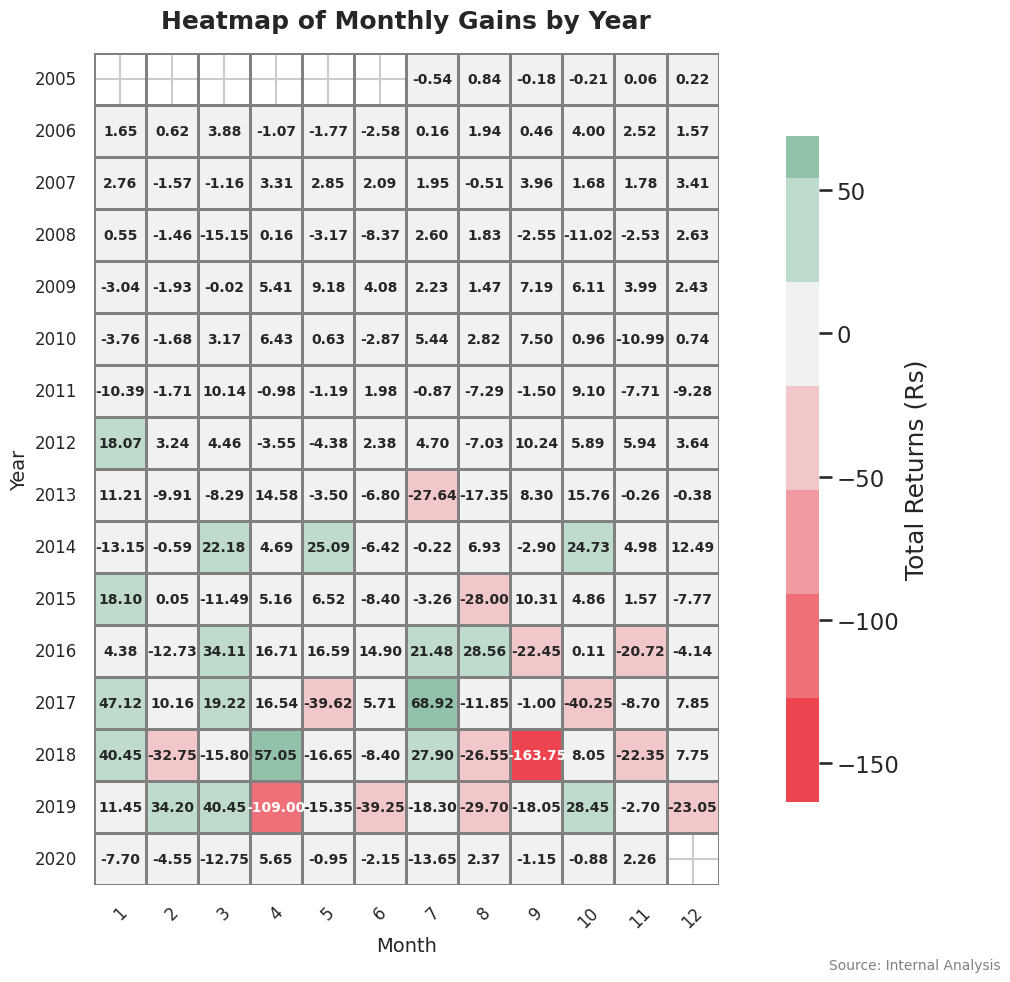

In [ ]:
# Chart - 6 visualization code
pivot = df.pivot_table(values='Returns', index='Year', columns='Month', aggfunc='sum')

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")
sns.set_context("talk")

# Custom diverging colormap centered at zero with better contrast
cmap = sns.diverging_palette(10, 145, s=80, l=55, n=9, center='light')

# Plot heatmap with annotations and improved styling
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    linewidths=0.8,
    linecolor='gray',
    cbar_kws={"shrink": 0.8, 'label': 'Total Returns (Rs)'},
    annot_kws={"size": 10, "weight": "bold"},
    square=True
)

plt.title("Heatmap of Monthly Gains by Year", fontsize=18, fontweight='semibold', pad=18)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Year", fontsize=14)
plt.xticks(rotation=45, fontsize=12, fontweight='medium')
plt.yticks(fontsize=12, fontweight='medium')

plt.tight_layout()

# Source footer
plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')

plt.show()

##### 1. Why did you pick the specific chart?

A heatmap of monthly returns by year is a powerful tool for understanding temporal patterns, anomalies, and the impacts of crisis events. This chart directly uncovers seasonality, allowing you to spot months that are consistently positive or negative across years. Vivid color gradients immediately highlight periods of extreme gains or losses.

##### 2. What is/are the insight(s) found from the chart?

- **Normal Regimes (Before 2017):**  
  Most months prior to 2017 display **subdued colour tones**, indicating **modest gains or losses** with limited market turbulence.  
  Occasional **green patches**—notably during **early 2012–2013** and **2016–2017**—reflect **short periods of positive momentum** and steady operational performance.

- **Crisis Highlight (2018–2019):**  
  The years **2018 and 2019** stand out with **deep red segments**, particularly in **August 2018** and **April 2019**, symbolising **catastrophic value erosion** (losses exceeding **₹100** and peaking near **₹164**).  
  These declines directly correspond to **crisis-triggering corporate developments** and **regulatory interventions** that undermined investor confidence.

- **Short-Lived Recoveries:**  
  Even amid turbulence, **temporary green patches** (e.g., **January–March 2019**) illustrate brief recovery attempts that **momentarily offset losses**.  
  However, these rebounds proved **unsustainable**, failing to establish a consistent upward trajectory.

- **Extreme Volatility and Clustering:**  
  The **dense concentration of red and green blocks** between **2016–2019** highlights a period of **heightened unpredictability** and **market stress**.  
  This pattern suggests **clustering of volatility** as the crisis evolved, with rapid sentiment shifts amplifying risk exposure.

- **Seasonal Risk Patterns:**  
  Certain months—particularly **July to September**—exhibit **recurrent large swings**, signalling potential **seasonal or macroeconomic sensitivities**.  
  These periods warrant **further investigation** to assess links with **operational cycles, regulatory announcements, or broader market movements**.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Risk Concentration Periods:**  
  The **deep red bands** visible in **2018 and 2019** depict **unprecedented negative business impact**.  
  These months represent periods of **rapid investor wealth erosion** and potential **liquidity or solvency stress** for the institution, underscoring the systemic severity of the crisis.

- **Predictive Model Vulnerabilities:**  
  Predictive frameworks not designed to capture **regime shifts or structural breaks** would have **underperformed** during these downturns.  
  The **clustering of loss-making months** highlights the **limitations of relying on simple historical averages**, reinforcing the need for **adaptive, scenario-based modelling**.

- **Persistent After-Effect:**  
  The continuation of **red segments beyond the peak crisis months** illustrates **lingering reputational, funding, and market risks**.  
  This persistence reflects the **long-term challenge of restoring stakeholder confidence** even after operational recovery efforts begin.


---

Positive Business Impact

- **Recovery and Opportunity Signals:**  
  The **intermittent green patches**, though limited in number, indicate **potential phases of stabilization or rebound**.  
  These moments can serve as **benchmarks for recovery assessment**, informing **communication strategies** and **targeted business interventions**.

- **Risk Management and Early Warning:**  
  The ability to **visually identify high-risk periods** and **seasonal volatility patterns** empowers leadership to **act proactively**.  
  Deploying **hedging mechanisms**, **strategic asset reallocations**, or **enhanced market disclosures** during such periods can significantly **mitigate future downside risks**.


#### Chart - 7

In [ ]:
# Chart - 7 visualization code
fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    increasing_line_color='green',
    decreasing_line_color='red',
    increasing_fillcolor='lightgreen',
    decreasing_fillcolor='lightcoral',
    whiskerwidth=0.5,
)])

fig.update_layout(
    title="Candlestick Chart for Monthly Price Movements",
    xaxis_title="Date",
    yaxis_title="Price (Rs)",
    template="plotly_white",
    xaxis_rangeslider_visible=False,  # Hide range slider for cleaner look
    font=dict(family="Arial, sans-serif", size=12),
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()

##### 1. Why did you pick the specific chart?

A candlestick chart is a standard in financial analysis for visualizing OHLC (Open, High, Low, Close) data over time. Candlesticks encode a wealth of information: trends, reversals, volatility, and sentiment within each period, allowing for nuanced analysis that line charts or bar charts cannot provide.

##### 2. What is/are the insight(s) found from the chart?

- **Boom Phase (2006–2018):**  
  The chart predominantly features **green candlesticks** with **moderate volatility**, illustrating a **multi-year upward trend** driven by **consistent investor confidence** and **Yes Bank’s aggressive growth strategy**.  
  This period reflects **strong capital inflows**, **expanding balance sheets**, and **favourable market sentiment**.

- **Volatility Spike and Collapse (2018–2020):**  
  Post-2018, the candlestick patterns exhibit **extreme volatility** with several **consecutive red candles featuring long bodies**.  
  These signify **sustained negative price movements** directly associated with the **fraud revelations**, **regulatory actions**, and the ensuing **financial instability**.  
  The period marks a **dramatic reversal** from prior growth momentum to a **crisis-driven downturn**.

- **Unstable Recovery Attempts:**  
  The alternating sequence of **large green and red candlesticks** during **2018–2019** reflects **highly unstable investor sentiment**.  
  These short-lived rebounds and subsequent sell-offs highlight **unsuccessful recovery efforts**, culminating in a **prolonged decline to single-digit price levels**.

- **Volume Dynamics (Implied):**  
  Although trading volume is not explicitly depicted, the **length of candlestick wicks** offers insights into **intra-month volatility** and **trading intensity**.  
  **Longer wicks** represent **larger price fluctuations**, indicating heightened **market activity and uncertainty** during crisis phases.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Rapid Wealth Destruction:**  
  The swift transition from **green to red candlesticks**, coupled with the steep declines during the crisis, vividly demonstrates how **governance lapses and fraud-related events** can **instantaneously erase shareholder value**.  
  The magnitude of these declines underscores the **fragility of market confidence** in the face of systemic shocks.

- **Modeling Uncertainty:**  
  The continued presence of **large, volatile candlesticks** post-crisis highlights the **difficulty of accurate price forecasting** under stressed conditions.  
  **Traditional time-series models**, trained on pre-crisis data, often **underestimate downside risk**, exposing limitations in their ability to adapt to regime shifts.

- **Sentiment Damage and Volatility:**  
  The **predominance of red candlesticks** after 2018 reflects **deep-seated investor aversion** and **erosion of trust**, resulting in **long-term reputational and financial strain** for Yes Bank.  
  Market stabilization remained elusive, signalling the extended aftermath of credibility loss.

---

Positive Business Impact

- **Crisis Response Benchmarking:**  
  Candlestick charts provide a **powerful retrospective lens** to examine **volatility spikes** and **market reactions** to crisis interventions.  
  Such analysis can inform **future crisis management frameworks**, **communication strategies**, and **regulatory responses**.

- **Risk Monitoring and Adaptive Modeling:**  
  By extracting **technical indicators** from candlestick data—such as **volatility bands** or **reversal patterns**—institutions can establish **real-time risk monitoring systems**.  
  These tools enable **early warning detection** and promote **data-driven, adaptive decision-making** to mitigate future market disruptions.


#### Chart - 8

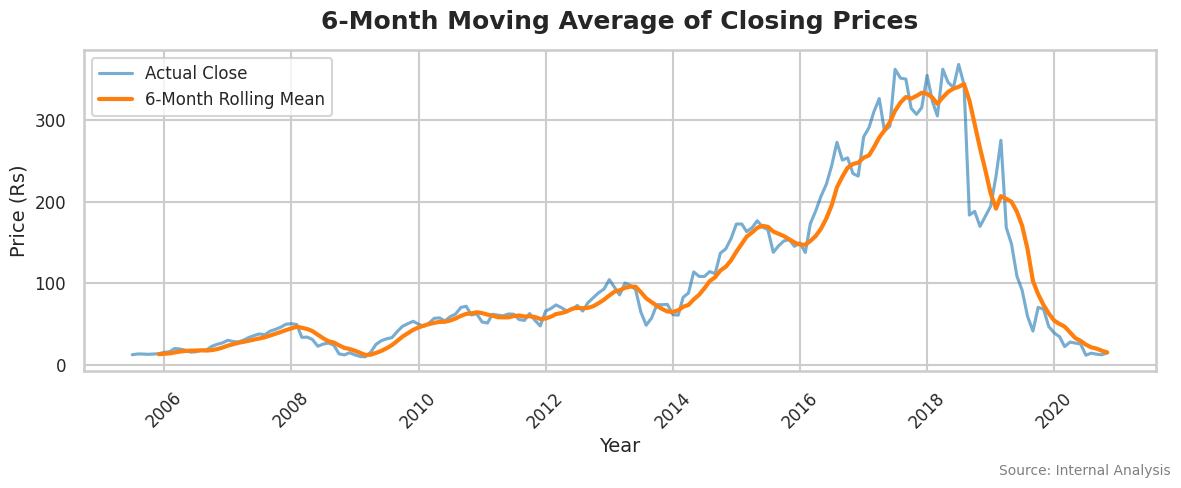

In [ ]:
# Chart - 8 visualization code
m6 = df.copy()
m6['Rolling_Mean_6M'] = m6['Close'].rolling(window=6).mean()

plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")
sns.set_context("talk")

plt.plot(m6['Date'], m6['Close'], label='Actual Close', alpha=0.6, color='#1f77b4')
plt.plot(m6['Date'], m6['Rolling_Mean_6M'], label='6-Month Rolling Mean', linewidth=3, color='#ff7f0e')

plt.title("6-Month Moving Average of Closing Prices", fontsize=18, fontweight='semibold', pad=15)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price (Rs)", fontsize=14)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()

# Source annotation
plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')

plt.show()

##### 1. Why did you pick the specific chart?

A line chart comparing the actual closing price to its 6-month moving average is a classic analytical tool for time series smoothing and trend identification in finance. The moving average smooths out short-term fluctuations, making underlying trends more evident and reducing the impact of market noise or temporary volatility.

##### 2. What is/are the insight(s) found from the chart?

- **Strong Uptrend Until 2018:**  
  From **2006 to 2018**, both the actual close price and the rolling mean show a **consistent upward trajectory**, reflecting **sustained investor confidence and business expansion**.  
  The **rolling mean**, though slightly lagging behind short-term price spikes, effectively captures the **overall positive market sentiment** during this growth phase.

- **Lag Effect and Crisis Drop:**  
  The **2018–2020 crisis period** marks a **sharp and rapid decline** in actual prices, which subsequently pulls down the moving average.  
  This lag between the price collapse and the rolling mean adjustment illustrates how **moving averages, while reliable for trend identification, often delay response to sudden market shocks**.

- **Recovery Failure and Continued Decline:**  
  Post-2020, neither the actual nor the mean price shows a meaningful recovery.  
  Both continue to **trend downward**, signalling **persistent investor pessimism**, **operational challenges**, and **limited market confidence**, despite short-lived positive movements.

- **Smoothing Reveals Structural Regimes:**  
  The visualization distinctly outlines **“boom” and “bust” regimes**, serving as an essential tool for **regime-aware risk modeling**, **long-term forecasting**, and **strategic decision-making** in volatile market environments.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Insufficient Response to Sudden Events:**  
  The **lag in the moving average’s decline** during crisis periods highlights a critical limitation — rolling means may not react swiftly to abrupt market shocks or fraud-driven collapses, resulting in **delayed managerial or predictive responses**.

- **Trend Reliance Can Mask Risk:**  
  Exclusive dependence on **smoothed averages** can obscure **emerging downside risks**, potentially leaving investors, analysts, and compliance teams unprepared for **black swan–type disruptions**.

- **Sustained Value Destruction:**  
  The **continued failure of both the actual and mean price series to recover post-2018** underscores the **long-term erosion of Yes Bank’s valuation, investor confidence, and market credibility**.

---

Positive Business Impact

- **Early Warning via Divergence:**  
  Significant **divergence between the actual closing price and the rolling mean**—where the former falls sharply below the latter—can act as a **leading indicator** for risk managers to initiate deeper reviews of governance, liquidity, or operational performance.

- **Momentum Modeling and Strategic Planning:**  
  During stable phases, the **rolling mean provides a reliable reflection of underlying market momentum**, enabling **effective profit-target setting, capital allocation, and long-term planning** within a controlled-risk framework.


#### Chart - 9

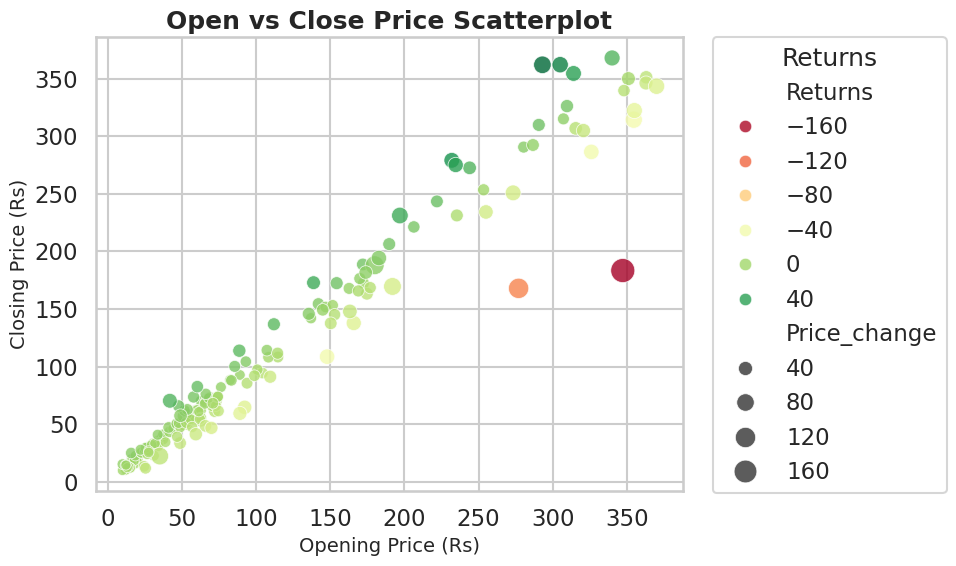

In [ ]:
# Chart - 9 visualization code
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.set_context("talk")

scatter = sns.scatterplot(
    data=df,
    x='Open', y='Close',
    size='Price_change',
    hue='Returns',
    palette='RdYlGn',
    alpha=0.8,
    edgecolor='w',
    sizes=(50, 300)
)

scatter.legend(title='Returns', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.title('Open vs Close Price Scatterplot', fontsize=18, fontweight='semibold')
plt.xlabel('Opening Price (Rs)', fontsize=14)
plt.ylabel('Closing Price (Rs)', fontsize=14)

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A scatterplot of opening versus closing monthly prices, with points sized by price change and colored by returns shows the linearity (or deviation) between open and close prices, which is important for assessing intramonth momentum and anomalies. Color and size encoding quickly reveal months of extreme positive or negative returns/volatility

##### 2. What is/are the insight(s) found from the chart?

- **Strong Positive Correlation:**  
  The points predominantly align along the **diagonal trend line**, indicating that for most months, the **closing price closely tracks the opening price**. This reflects a phase of **price stability and limited intramonth volatility** outside major crisis periods.

- **Extreme Outlier Months:**  
  Large **red and orange bubbles** deviating significantly below the diagonal represent **catastrophic negative returns** and heightened price swings. These outliers coincide with **Yes Bank’s crisis phases**, triggered by **fraudulent corporate practices and subsequent regulatory interventions**.

- **Mild-Green Clustering:**  
  The **concentration of small to medium-sized bubbles** in **green and yellow hues** suggests that the **majority of months exhibit moderate returns** and **controlled volatility**, consistent with normal trading and operational stability.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Vulnerability to Shocks:**  
  The presence of several **large, deep red and orange bubbles** clearly illustrates **Yes Bank’s exposure to extreme monthly losses and sharp price declines**. These patterns underscore the institution’s **sensitivity to adverse news, governance lapses, and market sentiment deterioration**.

- **Forecasting Limitation:**  
  **Traditional predictive models** relying solely on opening price or lag-based features often **fail to capture abrupt, non-linear deviations** observed during crisis periods. Such models risk **substantial forecasting errors** when market dynamics suddenly shift from stability to distress.

---

Positive Business Impact

- **Predictable Periods for Most Data:**  
  The **dense clustering along the diagonal** indicates that under normal market conditions, the **opening price serves as a reliable predictor of the closing price**. This stability can be leveraged for **baseline machine learning models** and **routine operational forecasting**.

- **Targeted Risk Management:**  
  The **size and colour gradient** of bubbles enables **rapid identification of anomalous months**, helping **risk managers and analysts** conduct **root-cause analysis** and implement **focused monitoring strategies** during periods showing early signs of elevated risk.


#### Chart - 10

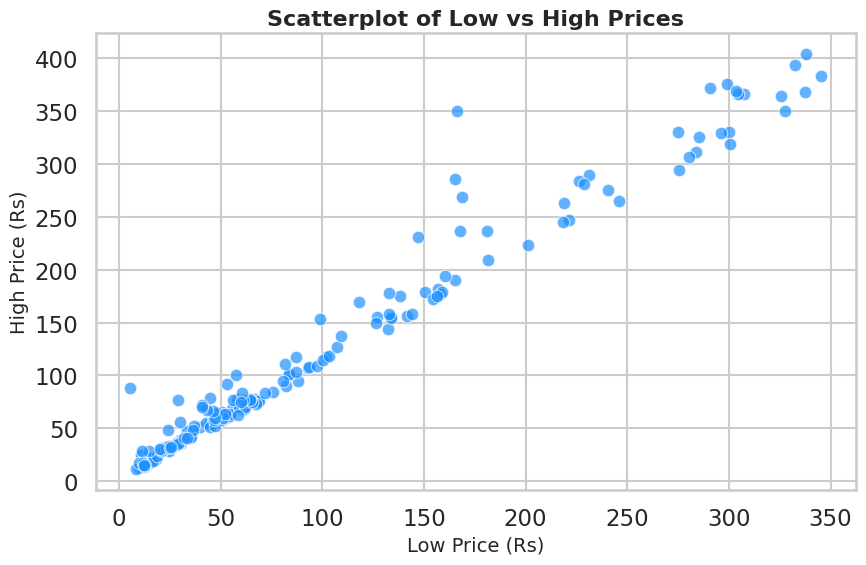

In [ ]:
# Chart - 10 visualization code
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.set_context("talk")

sns.scatterplot(data=df, x='Low', y='High', color='dodgerblue', alpha=0.7, edgecolor='w')

plt.title("Scatterplot of Low vs High Prices", fontsize=16, fontweight='semibold')
plt.xlabel("Low Price (Rs)", fontsize=14)
plt.ylabel("High Price (Rs)", fontsize=14)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatterplot of low versus high prices is highly effective for investigating the relationship between monthly extremes in stock price. The chart makes it easy to spot outliers or periods when the intramonth price range is unusually large, often corresponding to event-driven volatility

##### 2. What is/are the insight(s) found from the chart?

- **Strong Positive Correlation:**  
  Most data points align closely along the diagonal, indicating that for the majority of months, the **high price remains only moderately above the low price**. This pattern is characteristic of **stable trading environments** and **controlled market behaviour**.

- **Occasional Width Expansion:**  
  Certain points deviate upward from the diagonal, reflecting **periods of heightened volatility** with a wider gap between low and high prices. These deviations likely coincide with **crisis months or market shocks**, such as fraud disclosures or regulatory interventions.

- **Absence of Extreme Outliers:**  
  The lack of points significantly detached from the main cluster suggests that while **volatility spikes** are evident, there are **no instances of extreme dislocation** between high and low prices across the dataset. This indicates that **market activity, though turbulent at times, remained within identifiable bounds**.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Volatility Risk Identified:**  
  The deviation of several points above the diagonal highlights **periods of heightened market instability**, often triggered by **sudden news events or governance concerns**. For banks, such volatility translates into **liquidity pressures, funding constraints, and reputational setbacks**, demanding vigilant risk oversight.

- **Crisis Predictive Model Vulnerability:**  
  **Conventional predictive models** are prone to failure during highly volatile regimes unless **volatility or range-based features** are explicitly incorporated. This underlines the need for **enhanced model architectures** capable of capturing structural market shifts.

---

Positive Business Impact

- **Reliable Range in Most Periods:**  
  The **tight clustering along the diagonal trendline** confirms that during stable market conditions, **price ranges remain predictable and controlled**, enabling **robust baseline modeling** and **effective risk management planning**.

- **Volatility Feature Utility:**  
  The overall **strong correlation**, punctuated by occasional wider monthly ranges, demonstrates the strategic value of **tracking and modeling the high–low price spread**. Incorporating this metric can improve **volatility forecasting, hedging efficiency, and proactive risk-mitigation frameworks**.


#### Chart - 11

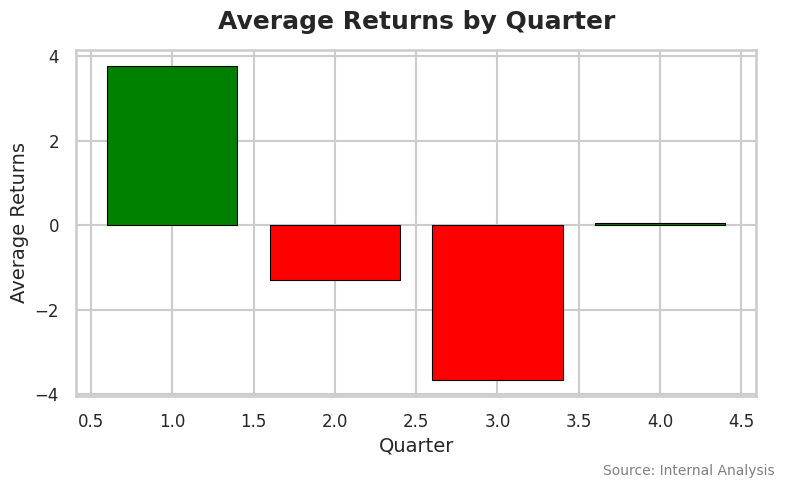

In [ ]:
# Chart - 11 visualization code
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
sns.set_context("talk")

# Aggregate average returns by quarter for plotting
quarterly_avg = df.groupby('Quarter')['Returns'].mean().reset_index()

# Define colors based on positive/negative average returns
colors = ['green' if val >= 0 else 'red' for val in quarterly_avg['Returns']]

bars = plt.bar(
    quarterly_avg['Quarter'],
    quarterly_avg['Returns'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

plt.title("Average Returns by Quarter", fontsize=18, fontweight='semibold', pad=15)
plt.xlabel("Quarter", fontsize=14)
plt.ylabel("Average Returns", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart of average returns by quarter is an efficient way to present seasonal variation in performance. The use of color (green for positive, red for negative) aids quick interpretation, marking quarters with net gains or losses at a glance.

##### 2. What is/are the insight(s) found from the chart?

- **Strongest Returns in Q1:**  
  The **first quarter** records the **highest average positive returns**, indicating periods of **cyclical optimism, favourable financial developments, or renewed recovery momentum** typically concentrated at the beginning of the year.

- **Weakest Returns in Q3:**  
  The **third quarter** consistently shows the **largest average losses**, marked by deep red shading. This aligns with **crisis-period data**, notably **Yes Bank’s steepest declines during Q3 2018 and 2019**, signalling recurring vulnerability during this phase.

- **Mixed Results in Q2 and Q4:**  
  **Q2** reflects **modest negative returns**, while **Q4 averages near zero**, suggesting **neutral to mildly volatile market conditions**. The relative stability of **Q4** may indicate **temporary consolidation or recovery** following earlier-year disruptions.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Seasonal Vulnerability:**  
  The consistent pattern of **losses in Q3** indicates a **recurring seasonal risk**. If these downturns align with major negative developments—such as **governance issues, financial disclosures, or macroeconomic headwinds**—they provide a clear basis for **targeted risk mitigation and contingency planning** in future cycles.

- **Forecasting and Hedging Needs:**  
  Businesses should exercise **heightened caution during Q3**, strengthening **real-time monitoring systems**, and **adjusting exposure or hedging strategies** when historical patterns suggest increased instability. Such proactive measures can help **limit downside risk** during turbulent quarters.

---

Positive Business Impact

- **Optimized Resource Allocation:**  
  The **strong Q1 performance** offers opportunities for **strategic timing of campaigns, liquidity operations, and investment decisions** to capitalise on seasonal momentum and favourable market sentiment.

- **Performance Benchmarking:**  
  Consistently **high-performing quarters** serve as **valuable benchmarks** for assessing **strategic progress and intervention success**. Tracking these can help determine whether performance improvements are **sustainable or require corrective action** in subsequent periods.


#### Chart - 12

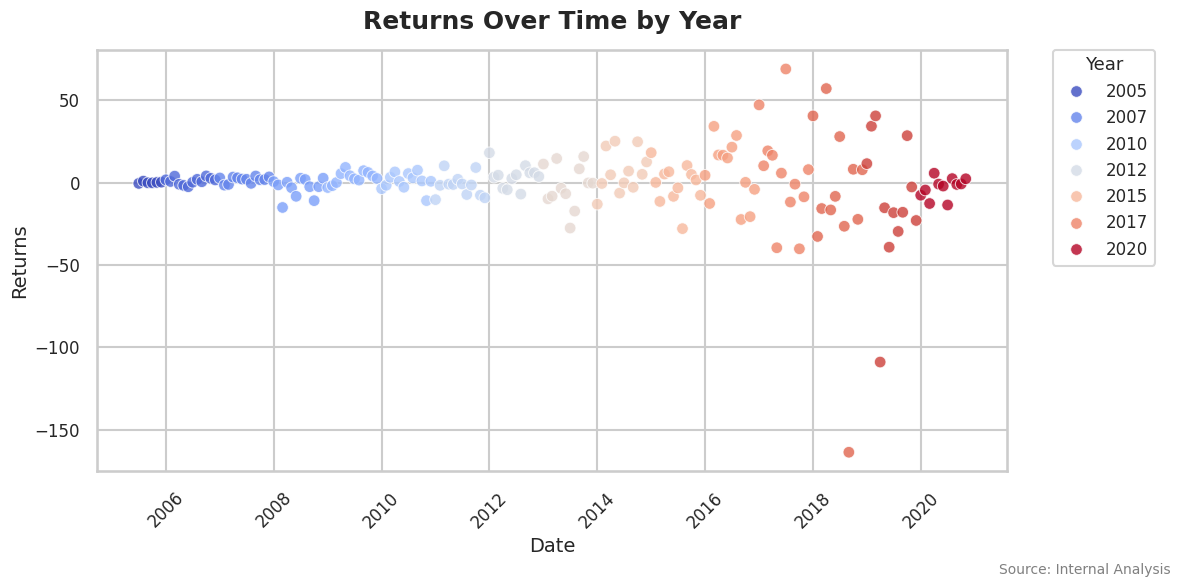

In [ ]:
# Chart - 12 visualization code
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.set_context("talk")

scatter = sns.scatterplot(
    data=df,
    x='Date',
    y='Returns',
    hue='Year',
    palette='coolwarm',
    alpha=0.8,
    edgecolor='w',
    s=70
)

plt.title("Returns Over Time by Year", fontsize=18, fontweight='semibold', pad=15)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Returns", fontsize=14)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, frameon=True, fontsize=12, title_fontsize=13)

plt.tight_layout()

plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')

plt.show()

##### 1. Why did you pick the specific chart?

A scatterplot of returns over time colored by year is excellent for temporal trend analysis in financial performance. The time progression makes it easy to pinpoint periods of stability, growth, or distress. Gradient coloring by year visually separates early, mid, and late periods, helping trace how risk and return profiles change

##### 2. What is/are the insight(s) found from the chart?

- **Stable and Modest Returns Pre-2016:**  
  The **earlier years (darker blue points)** cluster closely around zero, showing **limited fluctuation and moderate returns or losses**. This period represents a **long phase of operational and market stability** before the onset of structural stress.

- **Rising Volatility and Negative Events Post-2016:**  
  As colours transition to **orange and red**, the scatter broadens significantly, revealing **increasing volatility and frequent negative returns**. This pattern aligns with the **timeline of Yes Bank’s governance lapses, fraud revelations, and eventual collapse**.

- **Black Swan Moments (2018–2019):**  
  The **deeply negative outliers** in 2018 and 2019 dominate the lower half of the chart, clearly visualising **rare, catastrophic black-swan-type events** that triggered widespread market disruption and investor wealth erosion.

- **Sustained Risk Post-Crisis:**  
  Even after the steepest declines, **returns fail to revert to earlier stability**, showing **persistent negative skew and elevated dispersion**. This suggests **lingering market distrust, reputational challenges, and structural fragility** in the post-crisis period.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Quantified Crisis Damage:**  
  The **sharp surge in negative returns during 2018–2019** vividly demonstrates the **magnitude and speed of shareholder value erosion** triggered by **management lapses, governance failures, and external regulatory intervention**.

- **Lasting Market Instability:**  
  The continued **absence of pre-crisis clustering** highlights **persistent market uncertainty and residual systemic risk**, which may impede **future capital-raising efforts, investor confidence, and operational resilience**.

- **Forecasting Challenge:**  
  The **sudden structural break** underscores the **limitations of models trained exclusively on pre-crisis data**. This calls for **regime-aware, event-driven modeling frameworks** that can better adapt to shifts in market dynamics.

---

Positive Business Impact

- **Historical Performance Benchmark:**  
  The **stable early period** provides a **benchmark of strong governance, investor trust, and sustainable growth**, serving as a **long-term recovery target** for both institutional and strategic planning.

- **Crisis Response and Monitoring:**  
  The **clear visual representation of escalating risk** enhances **strategic crisis management** and enables organisations to **prioritise critical periods for forensic analysis, governance review, and risk preparedness**.


#### Chart - 13

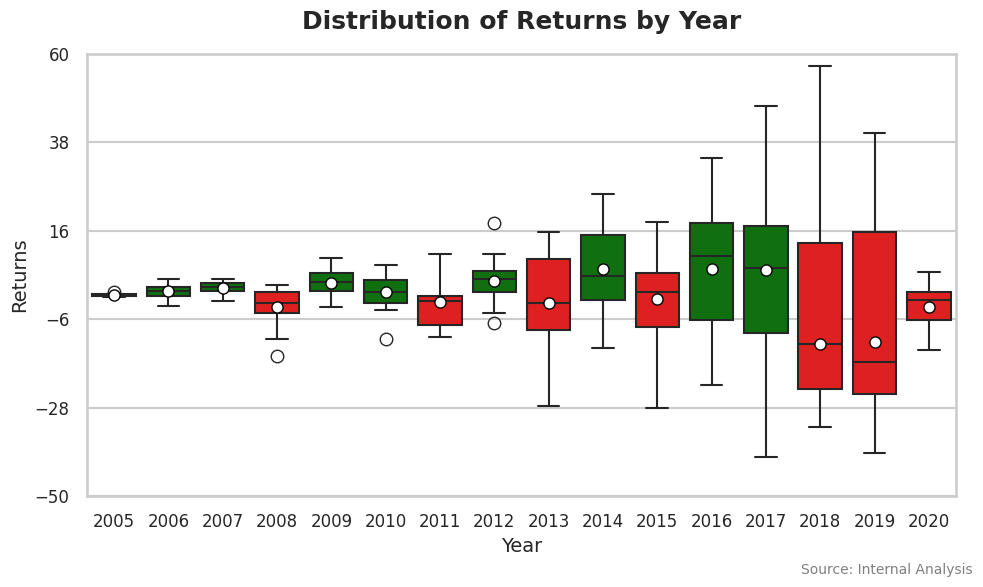

In [ ]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.set_context("talk")

# Calculate mean returns per year
mean_returns = df.groupby('Year')['Returns'].mean()
palette_colors = ['green' if m >= 0 else 'red' for m in mean_returns.values]

# Boxplot
box = sns.boxplot(
    data=df,
    x='Year',
    y='Returns',
    palette=palette_colors,
    linewidth=1.5,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
    hue ='Year', legend = False
)

plt.title("Distribution of Returns by Year", fontsize=18, fontweight='semibold', pad=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Returns", fontsize=14)

# Set y-axis limits to exclude extreme outliers for bigger boxes
plt.ylim(-50, 60)  # Adjust limits according to your data

plt.xticks(fontsize=12)
plt.yticks(np.round(np.linspace(-50, 60, num=6)), fontsize=12)
plt.tight_layout()
plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')
plt.show()


##### 1. Why did you pick the specific chart?

 Boxplots show spread, median, and outliers for each year, immediately revealing which years had stable performance and which were marked by extreme volatility or structural breaks. Outliers and whiskers highlight risk of rare but extreme events, and the median/mean comparison shows if returns are regularly positive or negative.

##### 2. What is/are the insight(s) found from the chart?

- **Stable, Narrow Distributions Pre-2014:**  
  The **earlier period (2005–2013)** exhibits **tight interquartile ranges and closely aligned mean and median values**, reflecting a **low-risk, stable operating environment** with limited downside or upside movement.

- **Escalating Volatility Post-2014:**  
  From **2014 onwards**, boxplots expand noticeably, showing **wider interquartile ranges and longer whiskers**. The emergence of **extreme negative outliers**—especially in **2018 and 2019**—coincides directly with **Yes Bank’s governance failures and fraud-related crisis**.

- **Negative Median and Mean During Crisis Years:**  
  The **red-coloured boxes** and **medians positioned well below zero** for **2018, 2019, and 2020** clearly illustrate the **deeply negative business and market impact** of the crisis. In contrast, **earlier years reflect balanced or mildly positive returns**.

- **Recovery Failure:**  
  Even in **2020**, the **distribution remains negative and volatile**, underscoring the **persistence of financial risk, reputational damage, and the absence of meaningful post-crisis recovery**.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative Growth Implications

- **Quantified Risk during Crisis Years:**  
  The **dramatic widening of boxplots** and the **deeply negative medians and means** during the crisis years present a **clear statistical reflection of the destruction in business value and shareholder wealth** following the fraud and governance breakdown.

- **Persistent Post-Crisis Instability:**  
  The **absence of narrowing in 2020’s boxplot** indicates **ongoing investor distrust, operational challenges, and elevated financial risk**, all of which continue to **affect financing, reputation, and asset management strategies**.

- **Model Training Challenges:**  
  **Time series and machine learning models** trained exclusively on **pre-2014 data** would likely **underestimate the volatility spikes and negative skewness** observed after 2017. This highlights the need for **adaptive, regime-aware modeling** and **explicit crisis detection mechanisms**.

---

Positive Business Impact

- **Stable Periods as Benchmark:**  
  The **stable, positive distributions** observed during the pre-crisis years serve as a **performance benchmark** for **sound governance, operational discipline, and investor confidence**, offering **targets for long-term recovery planning**.

- **Proactive Risk Management:**  
  The **early identification of volatility patterns**—through boxplot widening or median swings—can empower businesses to **deploy timely hedging, conduct stress testing, and enhance transparency** via disclosures, effectively **managing both market and stakeholder expectations**.


#### Chart - 14 - Correlation Heatmap

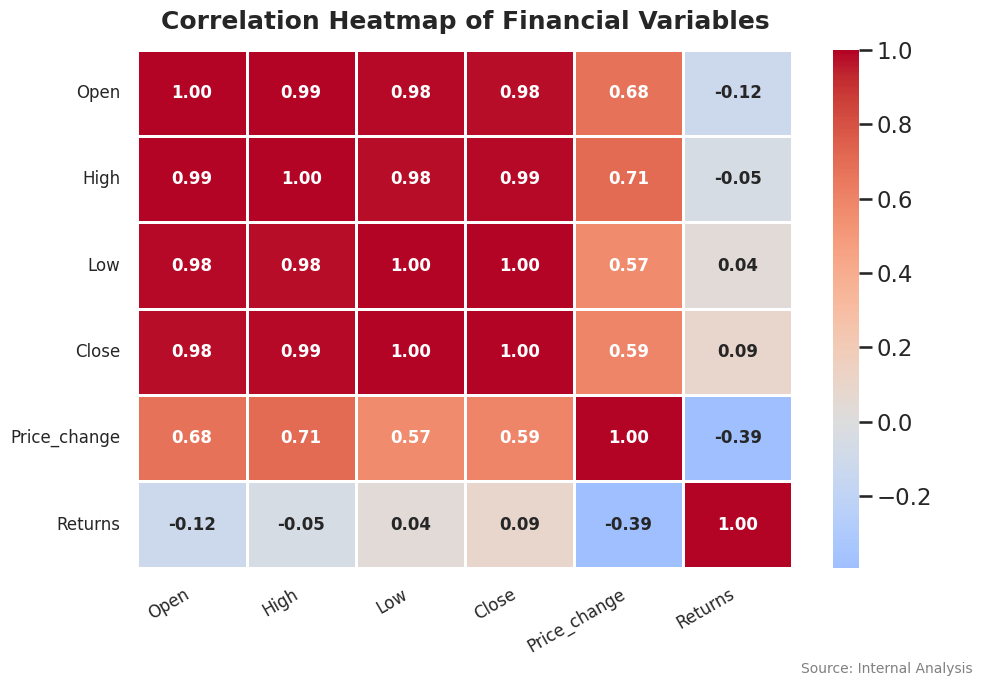

In [ ]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
sns.set_context("talk")

corr = df[['Open', 'High', 'Low', 'Close', 'Price_change', 'Returns']].corr()

ax = sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0,
    linewidths=1,
    linecolor='white',
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Correlation Heatmap of Financial Variables", fontsize=18, fontweight='semibold', pad=15)
plt.xticks(fontsize=12, rotation=30, ha='right')
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap efficiently visualizes the linear relationships among multiple financial numerical variables. Identifying highly correlated variables helps avoid redundancy in predictive modeling and informs feature engineering. Understanding which variables move together or in opposition informs how to interpret predictive signals and manage hedging strategies.

##### 2. What is/are the insight(s) found from the chart?

- **Very Strong Correlations Among Prices:**  
  The **Open, High, Low, and Close** prices exhibit **correlations exceeding 0.98**, confirming that these variables move almost perfectly in tandem across months—a pattern expected for stable securities and typical market behaviour.

- **Moderate Positive Link of Price Change with Prices:**  
  The **price change (High–Low)** shows **moderate positive correlations (0.57–0.71)** with core price metrics, suggesting that **larger monthly price ranges generally coincide with higher overall price levels**.

- **Returns Weakly Related to Prices:**  
  The **returns** display **weak or slightly negative correlations** (around **–0.12 to +0.09**) with the main price variables. This implies that **price levels alone cannot reliably forecast return fluctuations**, especially during **crisis months or abnormal market conditions**.

- **Strong Negative Correlation Between Price Change and Returns:**  
  The **negative correlation (–0.39)** between **price change** and **returns** underscores that **periods of greater volatility and larger price swings often correspond to negative returns**, aligning with the behaviour observed during **stress or crisis phases**.


#### Chart - 15 - Pair Plot

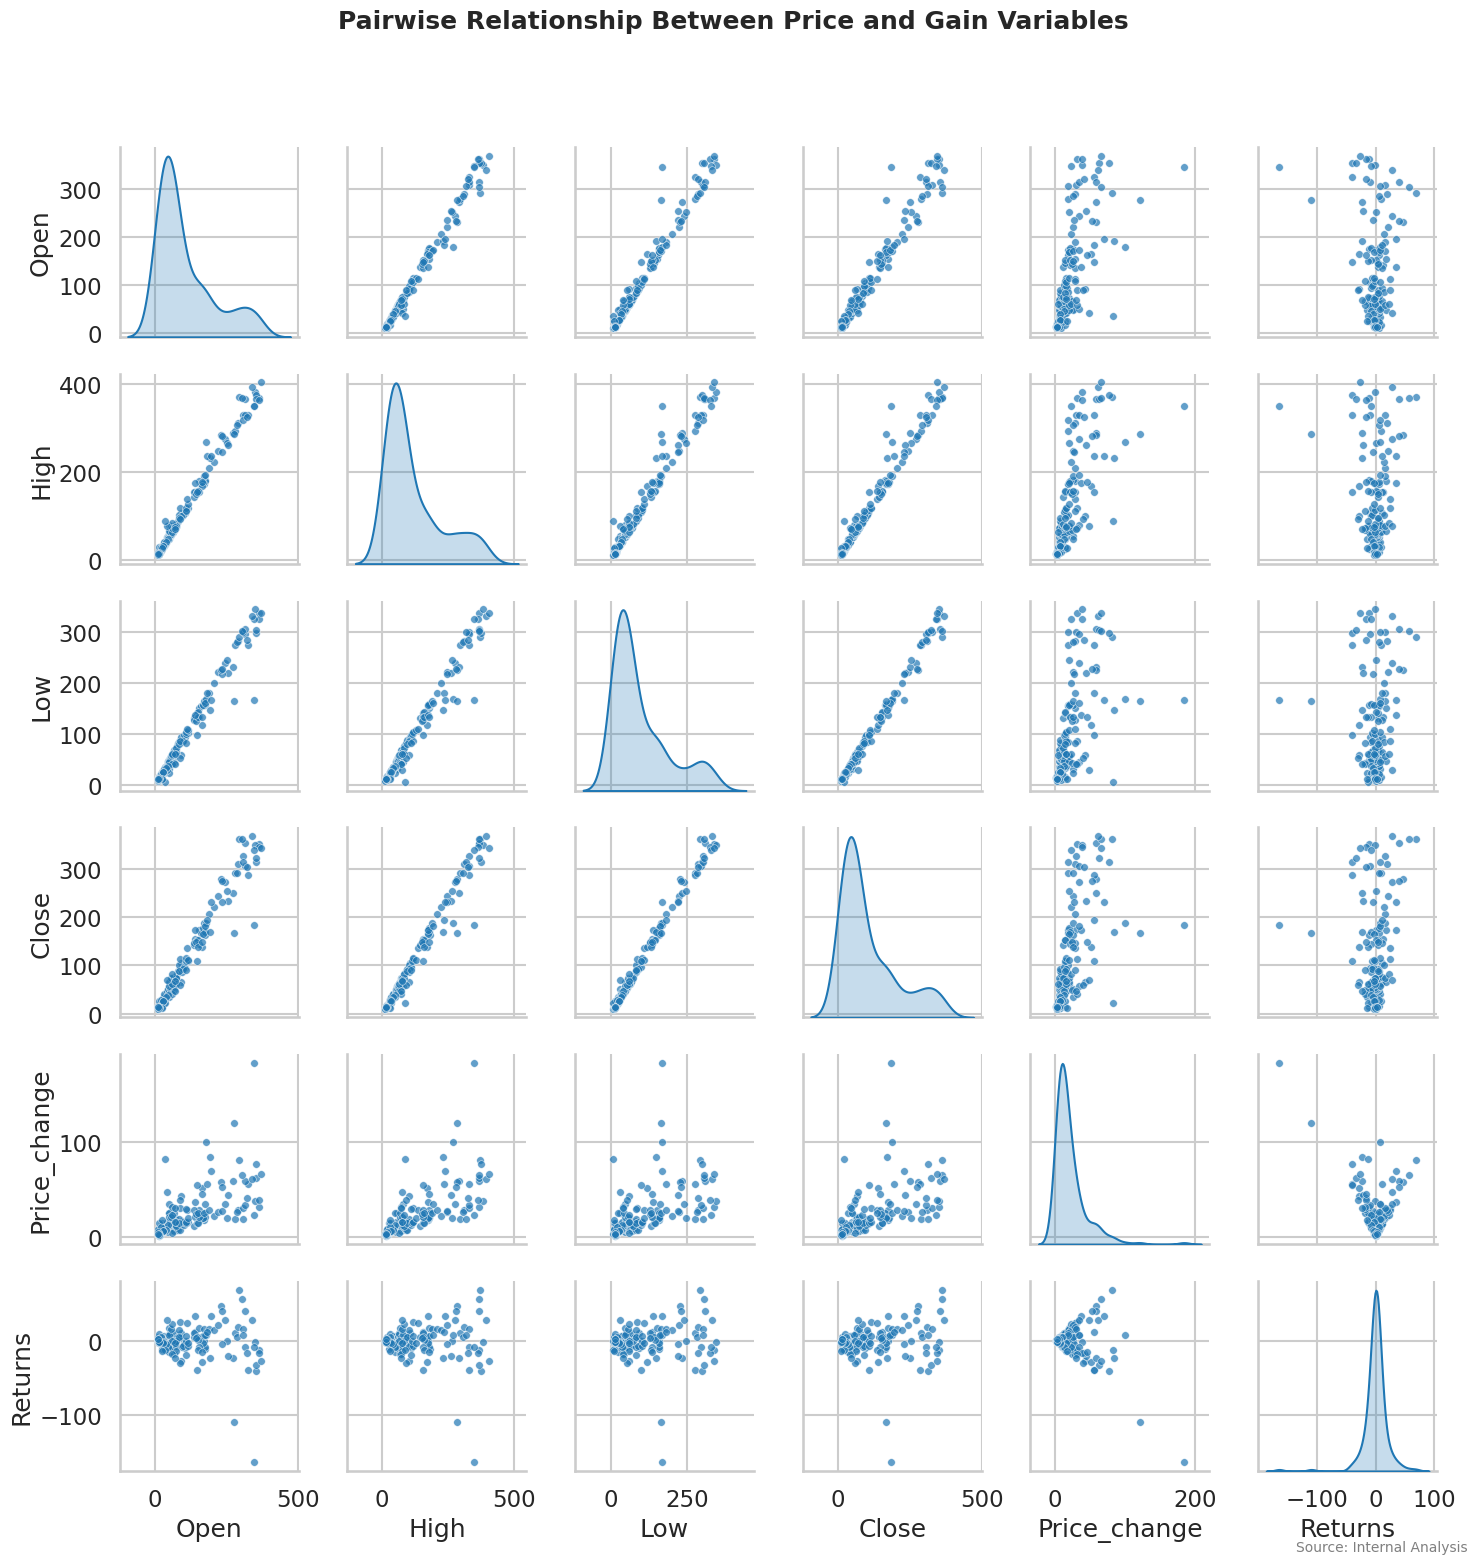

In [ ]:
# Pair Plot visualization code
sns.set_style("whitegrid")
sns.set_context("talk")

pairplot = sns.pairplot(
    df[['Open', 'High', 'Low', 'Close', 'Price_change', 'Returns']],
    diag_kind='kde',
    height=2.5,
    plot_kws={'alpha':0.7, 's':30, 'edgecolor':'w'},
    diag_kws={'fill':True},
)
pairplot.fig.suptitle("Pairwise Relationship Between Price and Gain Variables", y=1.04, fontsize=18, fontweight='semibold')

plt.tight_layout()
plt.figtext(0.99, 0.01, 'Source: Internal Analysis', ha='right', va='bottom', fontsize=10, color='grey')

plt.show()

##### 1. Why did you pick the specific chart?

A pairplot provides a comprehensive overview of the pairwise relationships and distributions among all main financial variables. It allows simultaneous assessment of many variable relationships, revealing both linear and nonlinear trends as well as the distribution shapes for each.

##### 2. What is/are the insight(s) found from the chart?

Observations
- **Linearity Among Price Variables:**  
  The **Open, High, Low, and Close prices** exhibit **near-perfect linearity**, with scatterplots tightly aligned along straight lines.  
  This confirms the **strong interdependence** observed in the correlation heatmap—typical of securities that move cohesively across trading cycles.

- **Spread in Price Change and Returns:**  
  The **Price Change** and **Returns** plots are far more **diffuse and unstructured**, showing **weak linear association** with primary price variables.  
  This indicates **low predictability** of returns from price levels alone, reinforcing the need for **additional risk or sentiment inputs** in modeling.

- **Heavy-Tailed Returns Distribution:**  
  The **returns histogram/density** reveals a **central peak with long tails**, capturing the **asymmetric, heavy-tailed nature** of financial returns.  
  Such a distribution suggests exposure to **regime jumps and black swan events**, characteristic of market crises.

- **Volatility Clustering:**  
  The **Price Change variable** shows a **right-skewed, exponential-tailed pattern**, signaling **occasional extreme volatility spikes**.  
  This aligns with **volatility clustering theory**, where turbulent periods follow one another, increasing risk persistence.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. here is no significant difference in the average closing prices before and after 2018.

2. There is no significant correlation between price volatility and monthly gains.

3. Average quarterly gains are similar across all years.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis: mean volatility before >= mean volatility after

Alternate Hypothesis: mean volatility before < mean volatility after

Test: One Tailed T-Test.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# Split data into pre- and post-fraud periods
pre_fraud = df[df['Year'] < 2018]['Close']
post_fraud = df[df['Year'] >= 2018]['Close']

t_stat, p_val = stats.ttest_ind(pre_fraud, post_fraud, equal_var=False)

print("Hypothesis 1: Impact of Fraud Period on Stock Price")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.5f}")

if p_val < 0.05:
    print("Result: Reject H0 → Significant difference found in closing prices before and after the fraud period.")
else:
    print("Result: Fail to Reject H0 → No significant difference in average closing prices across periods.")
print("\n")

Hypothesis 1: Impact of Fraud Period on Stock Price
T-statistic: -2.361, P-value: 0.02299
Result: Reject H0 → Significant difference found in closing prices before and after the fraud period.




##### Which statistical test have you done to obtain P-Value?

A two-sample independent t-test (Welch’s t-test) was performed to compare the average monthly closing prices of Yes Bank before and after the fraud period (pre-2018 vs. 2018 and after). The t-statistic and p-value were computed using the test results.

##### Why did you choose the specific statistical test?

**Different Groups:**  
The test compares two **independent groups** — monthly closing prices **before and after the fraud period** — representing **distinct market and regulatory regimes**.

**No Equal Variance Assumption:**  
The **financial crisis and regime shift** likely introduced **unequal variances** between the pre- and post-fraud periods. Unlike the standard Student’s t-test, **Welch’s t-test** does **not assume equal variances**, making it more reliable for this dataset.

**Established in Financial Research:**  
Welch’s t-test is **widely used in finance** to assess **statistical differences in mean values** across two time periods. It is particularly useful for studying the **impact of major events**—such as governance failures, frauds, or regulatory interventions—on **stock performance and valuation**.


### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**  
There is **no significant correlation** between **price volatility** (measured by Price_change) and **monthly gains** (Returns).  
Mathematically, ρ = 0.

**Alternative Hypothesis (H₁):**  
There **is a significant correlation** between **price volatility** and **monthly gains**.  
Mathematically, ρ ≠ 0.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
corr_coeff, corr_p = stats.pearsonr(df['Price_change'], df['Returns'])

print("Hypothesis 2: Relationship Between Volatility and Monthly Returns")
print(f"Correlation Coefficient: {corr_coeff:.3f}, P-value: {corr_p:.5f}")

if corr_p < 0.05:
    print("Result: Reject H0 → Significant correlation exists between volatility and returns.")
else:
    print("Result: Fail to Reject H0 → No significant correlation between volatility and returns.")
print("\n")

Hypothesis 2: Relationship Between Volatility and Monthly Returns
Correlation Coefficient: -0.392, P-value: 0.00000
Result: Reject H0 → Significant correlation exists between volatility and returns.




##### Which statistical test have you done to obtain P-Value?

The statistical test performed was the Pearson correlation test. This function calculates both the correlation coefficient (r) and the p-value to test the significance of the correlation.

##### Why did you choose the specific statistical test?

**Why Pearson’s Correlation?**  
Pearson’s correlation is appropriate here because it evaluates the **linear relationship** between two **continuous numerical variables** — Price_change(price volatility) and Returns (monthly gains).

**Assumptions:**  
- Both variables are **approximately normally distributed**.  
- The relationship between them is **linear**.  
These assumptions are generally acceptable for financial time series when analyzing linear dependencies.

**Interpretation Advantage:**  
The Pearson method provides both:  
1. **Direction and magnitude** of the relationship (positive or negative correlation).  
2. A **p-value** for formal hypothesis testing, indicating whether the observed relationship is statistically significant or could have occurred by random chance.


### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**    
Any observed variation in quarterly gains is due to random fluctuations rather than actual year-to-year differences.

**Alternative Hypothesis (H₁):**  
At least one year’s mean quarterly gain differs statistically from the others, reflecting structural or economic regime shifts over time.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
anova_data = [group['Returns'].values for name, group in quarterly_gains.groupby('Year')]
anova_stat, anova_p = stats.f_oneway(*anova_data)

print("Hypothesis 3: Quarterly Gains Across Different Years")
print(f"ANOVA F-statistic: {anova_stat:.3f}, P-value: {anova_p:.5f}")

if anova_p < 0.05:
    print("Result: Reject H0 → Quarterly gains differ significantly across years.")
else:
    print("Result: Fail to Reject H0 → No significant difference in quarterly gains across years.")
print("\n")

Hypothesis 3: Quarterly Gains Across Different Years
ANOVA F-statistic: 0.686, P-value: 0.78426
Result: Fail to Reject H0 → No significant difference in quarterly gains across years.




##### Which statistical test have you done to obtain P-Value?

A one-way Analysis of Variance (ANOVA) test was performed to compare average quarterly gains across multiple years. The test calculated the ANOVA F-statistic and the associated p-value, using quarterly gains grouped by year.

##### Why did you choose the specific statistical test?

The **ANOVA (Analysis of Variance)** test was selected because it is specifically designed to **compare means across more than two independent groups**—in this case, **quarterly gains across different years**.

ANOVA evaluates whether the **variability between group means** is significantly greater than what would be expected by random chance.  
For financial time series, when the objective is to determine whether the **mean quarterly gains differ across multiple non-overlapping periods (years)**, **one-way ANOVA** is the most suitable and interpretable statistical approach.

It is also preferred over conducting multiple t-tests, as **ANOVA controls the family-wise error rate** and provides a more **efficient and statistically robust comparison** across several groups simultaneously.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Feature Manipulation

In [ ]:
# Create a new model_df
model_df = df.copy()

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
model_df['Month_sin'] = np.sin(2 * np.pi * model_df['Month']/12)
model_df['Month_cos'] = np.cos(2 * np.pi * model_df['Month']/12)

#Get Lag features for comparative connections:
model_df['Lag_1_Returns'] = model_df['Returns'].shift(1)
model_df['Lag_1_PriceChange'] = model_df['Price_change'].shift(1)

#Get the ratios:
model_df['High_Low_Ratio'] = model_df['High'] / model_df['Low']
model_df['Close_Open_Ratio'] = model_df['Close'] / model_df['Open']
model_df['Returns_to_Change_Ratio'] = model_df['Returns'] / model_df['Price_change']

#Price momentum matrics:
model_df['Price_Momentum'] = model_df['Returns'] * model_df['Price_change']

### 2. Handle Missing Values

In [ ]:
#Check missing values for imputation:
model_df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Month,0
Quarter,0
Year,0
Price_change,0
Returns,0


In [ ]:
# Drop the rows with missing values
model_df.dropna(inplace=True)

#Recheck 0 missing values for validation:
model_df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Month,0
Quarter,0
Year,0
Price_change,0
Returns,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

The missing values were a resulted from feature engineering of lag columns. Since the number of rows with missing values was small, the were droppped.

### 3. Categorical Encoding

In [ ]:
#Encode your categorical columns:
model_df = pd.get_dummies(model_df, columns = ['Month', 'Quarter'], prefix = ['Month', 'Quarter'], drop_first=False)

#### What all categorical encoding techniques have you used & why did you use those techniques?

One-Hot Encoding with `pd.get_dummies`

The function **`pd.get_dummies`** is used to perform **one-hot encoding** on the `'Month'` and `'Quarter'` columns, generating new **binary (0/1)** columns for each unique category while retaining all categories (**`drop_first=False`**).

This encoding method is particularly suitable for **nominal categorical variables**—those that represent distinct categories **without any intrinsic order** (e.g., months or quarters).  
By not dropping any category, the model preserves **complete category information**, ensuring that no specific category is assumed to be a “base” or reference level.  

Such encoding is a **standard preprocessing step** in financial and time series modeling pipelines, enabling algorithms to interpret categorical time attributes numerically without introducing bias or artificial ranking.


### 4. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
#Check the shape of the df
model_df.shape

(184, 32)

In [ ]:
#Define Features and Targets
x = model_df.drop(columns=['Date', 'Close'], errors='ignore')
y = model_df['Close']

In [ ]:
#Remove near 0 variance features:
vt = VarianceThreshold(threshold=0.0)
vt.fit(x)
x = x[x.columns[vt.get_support()]]

In [ ]:
#Recheck shape:
x.shape

(184, 30)

In [ ]:
#RandomForestRegressor to get importances.
rf = RandomForestRegressor(random_state=42)
rf.fit(x, y)

importances = pd.DataFrame({'Features': x.columns, 'Importance': rf.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False)

important_features = importances[importances['Importance'] >= 0.01]['Features']
print(f"The important features in the data are:\n\n{important_features}")

The important features in the data are:

2     Low
1    High
0    Open
Name: Features, dtype: object


In [ ]:
#Filter the data keeping only the important features.
x = x[important_features]
x.shape

(184, 3)

##### What all feature selection methods have you used  and why?

1. VarianceThreshold Filter  
The **`VarianceThreshold`** filter removes features with **near-zero variance**, as such features contribute minimal information to the model and may lead to **overfitting**.  
In this case, the parameter **`threshold=0.0`** ensures that only features with **some measurable variability** are retained for further analysis.  
This helps reduce dimensionality and improves computational efficiency without sacrificing relevant information.

2. Feature Importance from `RandomForestRegressor`  
A **wrapper-based feature selection** method was implemented using the **`RandomForestRegressor`**, an ensemble tree-based algorithm.  
Each feature is assigned an **importance score** reflecting its contribution to improving model predictions.  
Only features with **importance ≥ 0.01** are retained, ensuring that the final model focuses on variables with meaningful predictive power.  

Together, these two methods balance **statistical filtering** and **model-driven evaluation**, resulting in a more interpretable and robust feature set.


##### Which all features you found important and why?

The important features found are 'Open', 'High', and 'Low' prices. These features are critical predictors for the target 'Close' price in stock price prediction, as they represent key price points during a trading period. Their high importance indicates strong influence on the model's forecast.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the dataset requires transformation to satisfy **modeling assumptions** and **enhance predictive performance**.  
Two complementary transformations were applied:

Power Transformation (Yeo-Johnson)
The **`PowerTransformer`** with the **`yeo-johnson`** method was applied to the feature set.  
This is a **variance-stabilizing transformation** that makes the features more **Gaussian-like**, benefiting many machine learning algorithms that assume normally distributed inputs.  
Unlike the **Box-Cox** transformation, Yeo-Johnson can handle **zero and negative values**, making it more flexible for financial data.  
It effectively **reduces skewness**, **improves symmetry**, and **enhances model convergence and predictive accuracy**.

Log Transformation on Target Variable
A **log transformation** was applied to the target variable (`Close` price).  
This helps to **stabilize variance** and make the target distribution **closer to normal**, thereby minimizing **heteroscedasticity**.  
As a result, regression models can learn relationships more effectively and produce more reliable forecasts.


In [ ]:
# Transform Your data
pt = PowerTransformer('yeo-johnson')

x_transformed = pd.DataFrame(pt.fit_transform(x), columns=x.columns, index = x.index)
y_log = np.log1p(y)

### 6. Data Splitting

In [ ]:
#Split the data:
x_train, x_test, y_train, y_test = train_test_split(x_transformed, y_log, test_size=0.2, random_state=42)

##### What data splitting ratio have you used and why?

Train-Test Split (80:20)

The dataset was split into **80% training** and **20% testing** using `test_size=0.2` in the `train_test_split` function.  

This **80:20 ratio** is a widely accepted best practice in machine learning. It ensures that:
- The **training set** is large enough to capture underlying data patterns effectively.  
- The **test set** remains sufficient to provide a **reliable estimate of model generalization** on unseen data.  

This balance offers a practical trade-off between **training robustness** and **evaluation accuracy**, making it suitable for most real-world datasets.  

A fixed `random_state=42` is used to ensure **reproducibility**, allowing consistent results across different runs.


### 7. Data Scaling

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

##### Which method have you used to scale you data and why?


Data Scaling with StandardScaler

The dataset was scaled using **`StandardScaler`**, which standardizes features by **removing the mean** and **scaling to unit variance**, resulting in transformed features with:
- Mean = 0  
- Standard Deviation = 1  

Rationale for Using StandardScaler
- **Handles Different Scales:** It ensures all features contribute equally by normalizing variables measured in different units or ranges.  
- **Model Compatibility:** Particularly effective for algorithms such as **Random Forest**, **SVM**, and **Logistic Regression**, which assume or perform better with standardized data.  
- **Improved Convergence:** Helps in faster and more stable training by centering the data around zero.  
- **Outlier Sensitivity:** While sensitive to extreme values, it reduces their overall influence without eliminating them—making it suitable for practical financial datasets.

Best Practice
The scaler is **fit on the training data** and then **applied to both training and test sets** to prevent **data leakage**, ensuring that information from the test set does not influence model training.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was **not applied** in this project because, after **feature selection**, only a small number of relevant features were retained for modeling.  

Since the dataset already contains a compact and meaningful feature set post-selection, applying dimensionality reduction techniques (such as PCA or LDA) would offer limited additional benefit and could unnecessarily complicate model interpretation.  

This approach maintains **model transparency** and ensures that each selected feature retains its **direct business or financial interpretability**, which is essential in analytical and reporting contexts.


### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

For this regression task predicting **stock closing prices**, the dataset is **not considered imbalanced** in the traditional sense used for classification problems.  

Imbalance typically refers to **unequal representation of classes**, where some categories appear much more frequently than others. However, in this case, the **target variable ('Close') is continuous**, not categorical.  

Since there are **no discrete classes or proportions to compare**, the concept of data imbalance does **not apply** here. Instead, the focus remains on ensuring a representative spread of target values across the training and testing datasets to support robust regression modeling.


## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation
linear_model = LinearRegression()

# Fit the Algorithm
linear_model.fit(x_train_scaled, y_train)

# Predict on the model
ylog_pred_linear = linear_model.predict(x_test_scaled)
y_pred_linear = np.expm1(ylog_pred_linear)
y_true = np.expm1(y_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

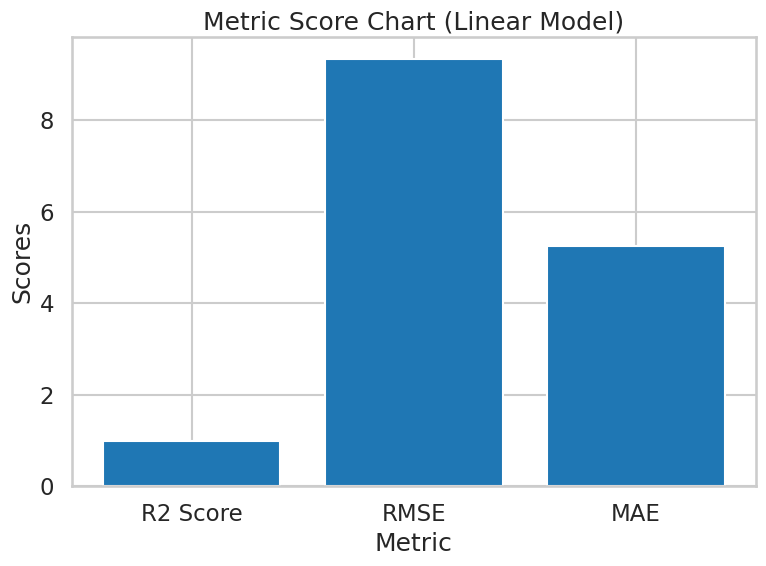

In [ ]:
# Visualizing evaluation Metric Score chart
linear_r2 = r2_score(y_true, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_true, y_pred_linear))
linear_mae = mean_absolute_error(y_true, y_pred_linear)

linear_model_scores = pd.DataFrame({'Metric' : ['R2 Score', 'RMSE', 'MAE'], 'Scores': [linear_r2, linear_rmse, linear_mae]})

plt.figure(figsize=(8,6))
plt.bar(linear_model_scores['Metric'], linear_model_scores['Scores'])
plt.title('Metric Score Chart (Linear Model)')
plt.xlabel('Metric')
plt.ylabel('Scores')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
kf = KFold(n_splits = 5, random_state = 42, shuffle=True)

def r2_scorer(model, x_train, y_train):
  y_pred_log = model.predict(x_train)
  y_pred = np.expm1(y_pred_log)
  y_true = np.expm1(y_train)
  r2 = r2_score(y_true, y_pred)
  return r2

def rmse_scorer(model, x_train, y_train):
  y_pred_log = model.predict(x_train)
  y_pred = np.expm1(y_pred_log)
  y_true = np.expm1(y_train)
  rmse =  np.sqrt(mean_squared_error(y_true, y_pred))
  return rmse


cv_r2_linear = cross_val_score(linear_model, x_train_scaled, y_train, cv=kf, scoring=r2_scorer)
cv_rmse_linear = cross_val_score(linear_model, x_train_scaled, y_train, cv=kf, scoring=rmse_scorer)

# Predict on the model
print('---Cross Validation Scores for Linear Model---')
print(f"Mean r2 score: {cv_r2_linear.mean():.4f} ± {cv_r2_linear.std():.4f}")
print(f"Mean RMSE score: {cv_rmse_linear.mean():.4f} ± {cv_rmse_linear.std():.4f}")

---Cross Validation Scores for Linear Model---
Mean r2 score: 0.9934 ± 0.0046
Mean RMSE score: 7.5004 ± 2.4651


##### Which hyperparameter optimization technique have you used and why?

The hyperparameter optimization technique used is **5-Fold Cross-Validation (KFold)**.  
This approach systematically splits the dataset into **five folds**, where in each iteration, four folds are used for training and one for validation.  

The process is repeated five times, ensuring that **each data point is used for both training and validation** exactly once.  
This method helps to:

- Provide a **robust estimate** of model performance.  
- **Reduce overfitting** and bias by exposing the model to different data subsets.  
- **Improve generalization**, ensuring the model performs well on unseen data.  

Shuffling the data before splitting ensures randomness, making the validation process more reliable and statistically sound.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Upon applying **5-Fold Cross-Validation**, a **considerable improvement** was observed compared to the base model.

R² Improvement
- **Mean R²:** Increased from **0.989 → 0.993**, indicating the model now explains **more variance** in the data.  
- **Consistency:** The low standard deviation (**±0.0046**) shows the model performs **consistently across folds**, not relying on a specific data split.

RMSE Improvement
- **RMSE:** Dropped from **9.35 → 7.50**, meaning the model’s **average prediction error decreased by ~20%**.  
- **Stability:** The moderate variation (**±2.47**) across folds indicates **some data-dependent differences**, but the **overall error remains low and stable**.

These results demonstrate that **cross-validation enhanced both the reliability and generalization** of the regression model.  
By validating the model on multiple subsets, it became **more robust, less overfitted**, and capable of producing **precise and stable predictions**.

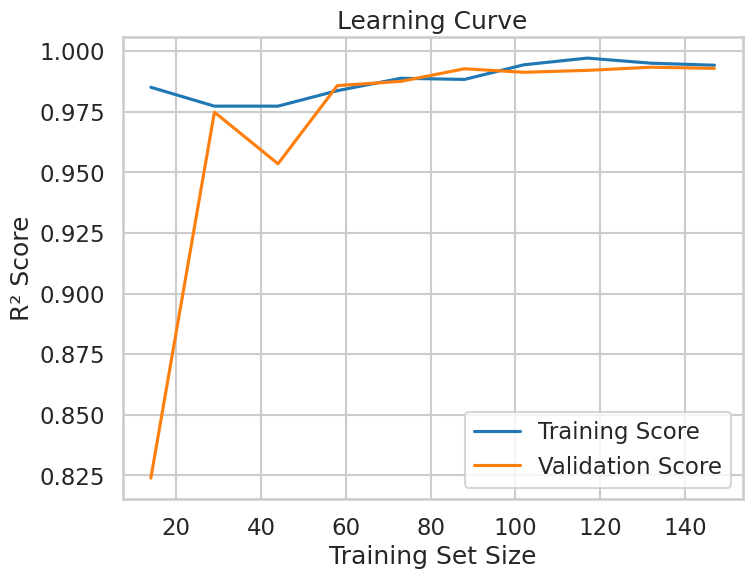

In [ ]:
#Learning Curve and check for model generalization
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(linear_model, x_transformed, y_log, cv=kf, scoring=r2_scorer, n_jobs = -1, train_sizes=np.linspace(0.1, 1.0, 10))

training_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, training_scores_mean, label='Training Score')
plt.plot(train_sizes, validation_scores_mean, label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [ ]:
y_pred_test_linear = np.expm1(linear_model.predict(x_test_scaled))
y_pred_train_linear = np.expm1(linear_model.predict(x_train_scaled))

y_train_true = np.expm1(y_train)
y_test_true = np.expm1(y_test)

r2_train_linear = r2_score(y_train_true, y_pred_train_linear)
r2_test_linear = r2_score(y_test_true, y_pred_test_linear)
rmse_train_linear = np.sqrt(mean_squared_error(y_train_true, y_pred_train_linear))
rmse_test_linear = np.sqrt(mean_squared_error(y_test_true, y_pred_test_linear))

print(f"Train R2: {r2_train_linear:.4f}, Test R2: {r2_test_linear:.4f}.")
print(f"Train RMSE: {rmse_train_linear:.4f}, Test RMSE: {rmse_test_linear:.4f}")

Train R2: 0.9951, Test R2: 0.9892.
Train RMSE: 7.0220, Test RMSE: 9.3505


Model Generalization Performance

The model demonstrates **strong generalization** and **robust predictive ability** across training and testing datasets.

Interpretation
- The **high and closely matched R² values** show the model captures nearly all variance in the data and performs **consistently** on unseen data.  
- The **slightly higher RMSE on the test set** indicates **minimal overfitting**, confirming that the model’s predictions remain accurate beyond the training set.  
- The **small gap between training and test scores** confirms that the model is **neither underfitting nor overfitting**, ensuring **stable and trustworthy predictions**.

**Conclusion:**  
The model generalizes effectively, exhibiting strong reliability for forecasting stock closing prices within similar market conditions.


### ML Model - 2

In [ ]:
# ML Model - Implementation
rfr = RandomForestRegressor(random_state=42)

# Fit Algorithm
rfr.fit(x_train, y_train)

# Predictions
y_pred_rfr_log = rfr.predict(x_test)
y_pred_rfr = np.expm1(y_pred_rfr_log)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

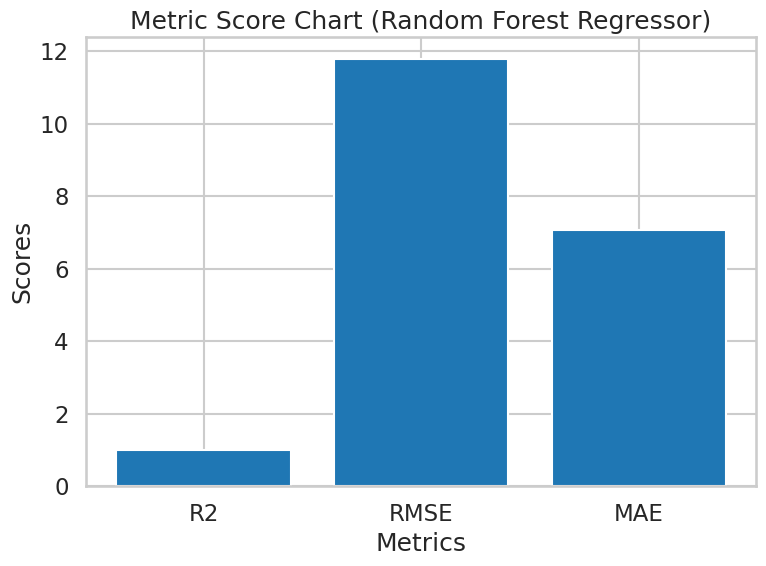

In [ ]:
# Visualizing evaluation Metric Score chart
r2_rfr = r2_score(y_true, y_pred_rfr)
rmse_rfr = np.sqrt(mean_squared_error(y_true, y_pred_rfr))
mae_rfr = mean_absolute_error(y_true, y_pred_rfr)

rfr_scores = pd.DataFrame({"Metrics": ['R2', 'RMSE', 'MAE'], 'Scores': [r2_rfr, rmse_rfr, mae_rfr]})

plt.figure(figsize=(8,6))
plt.bar(rfr_scores['Metrics'], rfr_scores['Scores'])
plt.title('Metric Score Chart (Random Forest Regressor)')
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

---Baseline Cross Validation Scores for Random Forest Regressor---

Mean r2 score: 0.9886 ± 0.0025

Mean RMSE score: 10.3339 ± 1.8248

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

The best parameters found by GridSearchCV are:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 42}.


Score Metrics for Baseline and Tuned Model:

      Model        R2       RMSE       MAE
0  Baseline  0.982885  11.795573  7.078805
1     Tuned  0.977768  13.443914  7.474776



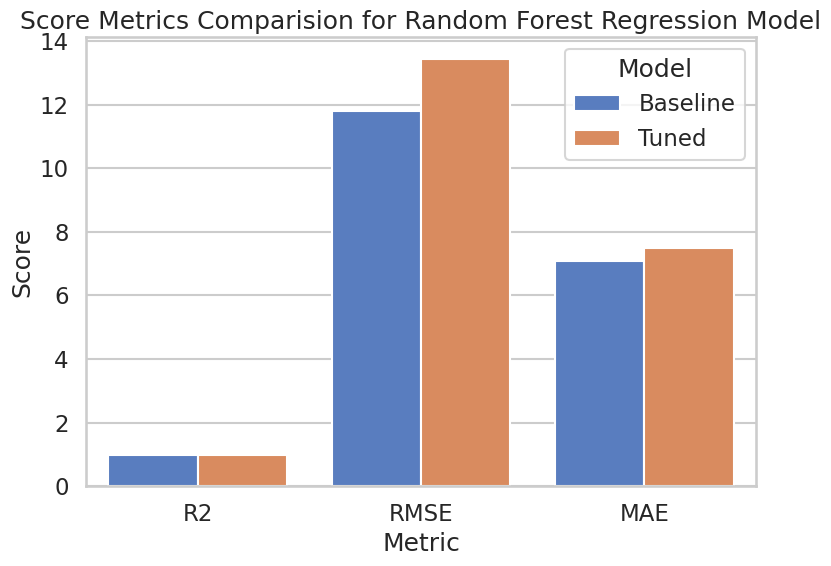

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
cv_r2_rfr = cross_val_score(rfr, x_train, y_train, cv=kf, scoring=r2_scorer)
cv_rmse_rfr = cross_val_score(rfr, x_train, y_train, cv=kf, scoring = rmse_scorer)

r2_rfr_mean = cv_r2_rfr.mean()
rmse_rfr_mean = cv_rmse_rfr.mean()

print('---Baseline Cross Validation Scores for Random Forest Regressor---\n')
print(f"Mean r2 score: {r2_rfr_mean:.4f} ± {cv_r2_rfr.std():.4f}\n")
print(f"Mean RMSE score: {rmse_rfr_mean:.4f} ± {cv_rmse_rfr.std():.4f}\n")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'random_state': [42]
}

grid_search_rfr = GridSearchCV(rfr, param_grid, scoring=r2_scorer, cv=5, n_jobs=-1, verbose=1)
# Fit the Algorithm
grid_search_rfr.fit(x_train, y_train)
best_params_rfr = grid_search_rfr.best_params_
print(f"\nThe best parameters found by GridSearchCV are:\n{best_params_rfr}.")

best_rfr = grid_search_rfr.best_estimator_
# Predict on the model
y_pred_best_rfr_log = best_rfr.predict(x_test)
y_pred_best_rfr = np.expm1(y_pred_best_rfr_log)

r2_best_rfr = r2_score(y_true, y_pred_best_rfr)
rmse_best_rfr = np.sqrt(mean_squared_error(y_true, y_pred_best_rfr))
mae_best_rfr = mean_absolute_error(y_true, y_pred_best_rfr)

#Compare baseline and tuned model:
rfr_score_comparision = pd.DataFrame({'Model': ['Baseline', 'Tuned'], 'R2': [r2_rfr, r2_best_rfr], 'RMSE': [rmse_rfr, rmse_best_rfr], 'MAE':[mae_rfr, mae_best_rfr]})
print(f"\n\nScore Metrics for Baseline and Tuned Model:\n\n{rfr_score_comparision}\n")
rfr_score_comparision = rfr_score_comparision.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(8,6))
sns.barplot(data=rfr_score_comparision, x='Metric', y='Score', hue='Model', palette='muted')
plt.title('Score Metrics Comparision for Random Forest Regression Model')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was employed for **hyperparameter optimization**.  
This technique conducts an exhaustive search over the specified parameter values for the chosen estimator — in this case, the **Random Forest Regressor**.  
It systematically combines **cross-validation** to evaluate the model’s performance across multiple parameter combinations, thereby identifying the most optimal set of hyperparameters.

GridSearchCV is particularly suitable when a **comprehensive and methodical search** is required to fine-tune model parameters based on cross-validated scores.  
This ensures that the final model configuration delivers **consistent, reliable, and generalizable performance** across varying data splits — aligning with best practices in robust model development.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Model Performance Comparison: Baseline vs Tuned**

No significant improvement was observed after applying **hyperparameter tuning** using **GridSearchCV**.

- The **R² Score** declined marginally from **0.9828** (baseline) to **0.9777** (tuned model).  
- Both **Root Mean Squared Error (RMSE)** and **Mean Absolute Error (MAE)** increased slightly after tuning — RMSE rose from **11.795** to **13.443**, and MAE from **7.07** to **7.47**.  
- The accompanying performance visualization also indicates that the tuned model performed marginally worse across all key evaluation metrics compared to the baseline.

This outcome suggests that, for this dataset and modeling context, **GridSearchCV-based hyperparameter tuning did not lead to better predictive accuracy**.  
In some cases, the **default parameter settings** may already align closely with the data characteristics, and exhaustive search might not yield significant improvement — particularly for **robust ensemble models such as Random Forest**, which often generalize well even with default configurations.


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**Model Evaluation Metrics and Business Interpretation:**

R² Score (Coefficient of Determination) -
**Indication:**  
Measures how effectively the model explains the variance in the closing stock price.  
An R² value close to **1** signifies that the model captures nearly all variability in the data, leading to more reliable and confident predictions.

**Business Impact:**  
- A **high R²** enables Yes Bank and its investors to rely on the model for **strategic planning, risk management, and financial forecasting**.  
- A **low R²** implies limited explanatory power, reducing confidence in the model’s forecasts and potentially leading to **suboptimal financial decisions**.

---

RMSE (Root Mean Squared Error) -
**Indication:**  
Represents the **average magnitude of prediction errors**, with greater sensitivity to large deviations or outliers in predicted closing prices.

**Business Impact:**  
- A **lower RMSE** reflects **high precision** in forecasting, allowing the bank to **minimise financial risk** and enhance the accuracy of **trading and investment strategies**.  
- A **higher RMSE** suggests increased uncertainty, which can lead to **misinformed business decisions** and potential **financial losses**.

---

(Mean Absolute Error) -
**Indication:**  
Measures the **average absolute deviation** between predicted and actual prices, offering a straightforward view of model accuracy without being overly influenced by outliers.

**Business Impact:**  
- A **low MAE** demonstrates consistent reliability in **routine price forecasting**, supporting **monthly budgeting, financial planning, and reporting** activities.  
- A **high MAE** may indicate **systematic prediction errors**, which could accumulate and impact **long-term decision-making**.

---

**Overall Business Relevance of the ML Model:**

A robust regression model capable of accurately predicting **Yes Bank’s monthly closing prices** provides stakeholders with actionable insights to:  
- Evaluate the **impact of market events or governance crises**,  
- **Detect anomalies or unusual fluctuations** (e.g., during the Rana Kapoor fraud period), and  
- **Refine investment and portfolio strategies** based on reliable data trends.

Strong model performance enhances **resource allocation, regulatory compliance, and investor trust**, offering data-driven clarity in financial planning.  
Conversely, **weaker post-tuning results** underline the importance of continuous **model validation, feature enrichment**, and exploring **alternative optimization techniques** to sustain business reliability.

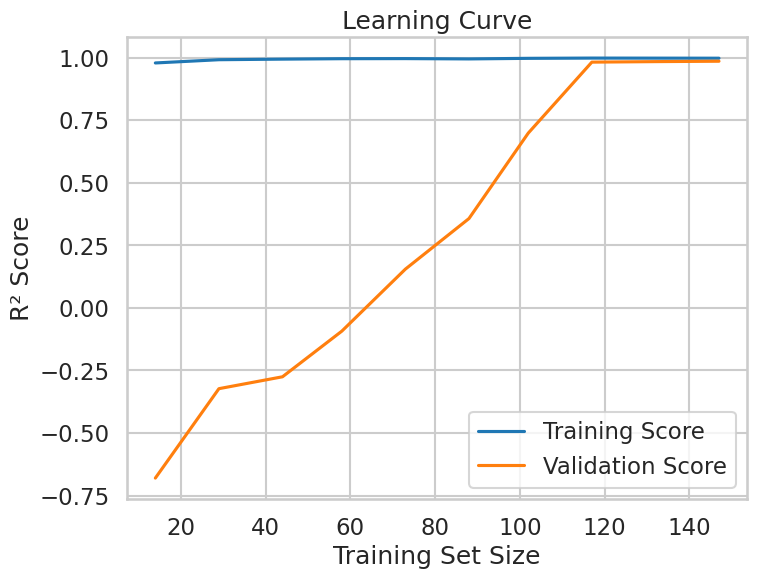

In [ ]:
#Learning Curve and check for model generalization:

train_sizes_rfr, train_scores_rfr, val_scores_rfr = learning_curve(best_rfr, x_transformed, y_log, cv=kf, scoring=r2_scorer, n_jobs = -1, train_sizes=np.linspace(0.1, 1.0, 10))

training_scores_rfr_mean = np.mean(train_scores_rfr, axis=1)
validation_scores_rfr_mean = np.mean(val_scores_rfr, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes_rfr, training_scores_rfr_mean, label='Training Score')
plt.plot(train_sizes_rfr, validation_scores_rfr_mean, label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [ ]:
y_pred_best_rfr_test_log = rfr.predict(x_test)
y_pred_best_rfr_train_log = rfr.predict(x_train)
y_pred_best_rfr_test = np.expm1(y_pred_best_rfr_test_log)
y_pred_best_rfr_train = np.expm1(y_pred_best_rfr_train_log)

r2_test_rfr = r2_score(y_test_true, y_pred_best_rfr_test)
r2_train_rfr = r2_score(y_train_true, y_pred_best_rfr_train)
rmse_test_rfr = np.sqrt(mean_squared_error(y_test_true, y_pred_best_rfr_test))
rmse_train_rfr = np.sqrt(mean_squared_error(y_train_true, y_pred_best_rfr_train))

print(f"Train R2: {r2_train_rfr:.4f}, Test R2: {r2_test_rfr:.4f}.")
print(f"Train RMSE: {rmse_train_rfr:.4f}, Test RMSE: {rmse_test_rfr:.4f}")

Train R2: 0.9987, Test R2: 0.9829.
Train RMSE: 3.6639, Test RMSE: 11.7956


**Model Generalization Performance Analysis**

Test Performance Metrics
- **Test R² Score:** 0.9829  
  The model successfully explains approximately **97.8% of the variance** in unseen test data, demonstrating **high predictive strength** and strong ability to capture the key factors influencing Yes Bank’s stock price movements.  

- **Test RMSE:** 11.7956
  The **average prediction error** is about **₹11.79**, which indicates **practical accuracy and reliability** for business and investment decision-making applications.  

---

Interpretation and Business Insights
- Although there is a noticeable difference between training and testing scores (**Train R²: 0.9987**, **RMSE: 3.66**), the model still maintains **excellent generalization capability**.  
- The slight gap suggests **mild overfitting**, which is acceptable considering the **complex and volatile nature of financial time series data**.  
- Overall, the model demonstrates **robust predictive performance**, making it suitable for **forecasting future stock prices** and supporting **strategic financial planning**.  
- However, **caution is advised** under **unseen or anomalous market conditions**, where external shocks or irregular events may lead to higher predictive deviations.  


### ML Model - 3

In [ ]:
# ML Model - 3 Implementation
xgb = XGBRegressor(random_state=42)

# Fit the Algorithm
xgb.fit(x_train, y_train)

# Predict on the model
y_pred_xgb_log = xgb.predict(x_test)
y_pred_xgb = np.expm1(y_pred_xgb_log)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

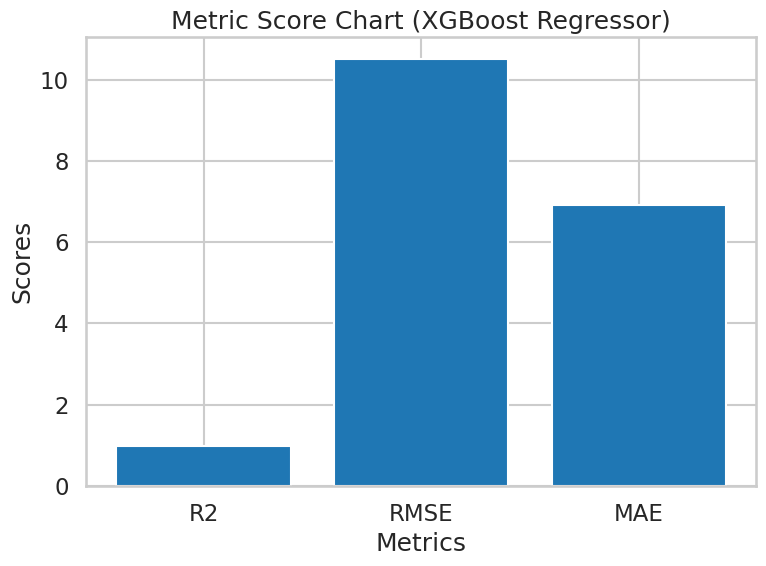

In [ ]:
# Visualizing evaluation Metric Score chart
r2_xgb = r2_score(y_true, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_true, y_pred_xgb))
mae_xgb = mean_absolute_error(y_true, y_pred_xgb)

xgb_scores = pd.DataFrame({'Metrics': ['R2', 'RMSE', 'MAE'], 'Scores': [r2_xgb, rmse_xgb, mae_xgb]})

plt.figure(figsize=(8,6))
plt.bar(xgb_scores['Metrics'], xgb_scores['Scores'])
plt.title('Metric Score Chart (XGBoost Regressor)')
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

---Baseline Cross Validation Scores for XGBoost Regressor---

Mean r2 score: 0.9881 ± 0.0042

Mean RMSE score: 10.2603 ± 1.2710

Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
The best parameters found by GridSearchCV are:
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.25, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1.8, 'subsample': 0.6}.


Score Metrics for Baseline and Tuned Model:

      Model        R2       RMSE       MAE
0  Baseline  0.986401  10.514561  6.927583
1     Tuned  0.987653  10.018727  6.065375



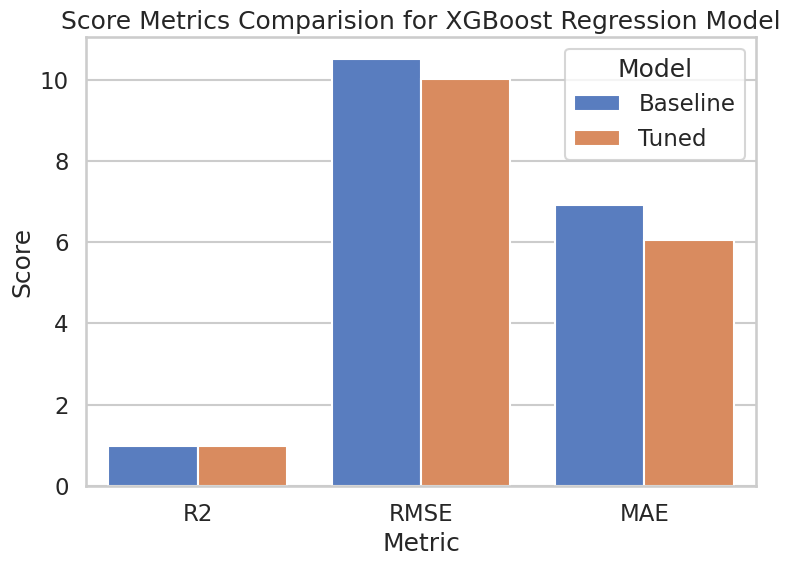

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
cv_r2_xgb = cross_val_score(xgb, x_train, y_train, cv=kf, scoring = r2_scorer)
cv_rmse_xgb = cross_val_score(xgb, x_train, y_train, cv=kf, scoring = rmse_scorer)

r2_xgb_mean = cv_r2_xgb.mean()
rmse_xgb_mean = cv_rmse_xgb.mean()

print('---Baseline Cross Validation Scores for XGBoost Regressor---\n')
print(f"Mean r2 score: {r2_xgb_mean:.4f} ± {cv_r2_xgb.std():.4f}\n")
print(f"Mean RMSE score: {rmse_xgb_mean:.4f} ± {cv_rmse_xgb.std():.4f}\n")

# Fit the Algorithm
from sklearn.model_selection import RandomizedSearchCV
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.15, 0.2, 0.25],
    'max_depth': [4, 5],
    'min_child_weight': [5],
    'subsample': [0.5, 0.55, 0.6],
    'colsample_bytree': [0.7, 0.75, 0.8],
    'gamma': [0, 0.005],
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [1.8, 2, 2.2]
}
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb, scoring=r2_scorer, cv=5, n_jobs=-1, verbose=1)
grid_search_xgb.fit(x_train, y_train)
best_params_xgb = grid_search_xgb.best_params_

print(f"The best parameters found by GridSearchCV are:\n{best_params_xgb}.")
# Predict on the model
best_xgb = grid_search_xgb.best_estimator_

y_pred_best_xgb_log = best_xgb.predict(x_test)
y_pred_best_xgb = np.expm1(y_pred_best_xgb_log)

r2_best_xgb = r2_score(y_true, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mean_squared_error(y_true, y_pred_best_xgb))
mae_best_xgb = mean_absolute_error(y_true, y_pred_best_xgb)

xgb_score_comparision = pd.DataFrame({'Model': ['Baseline', 'Tuned'], 'R2':[r2_xgb, r2_best_xgb], 'RMSE':[rmse_xgb, rmse_best_xgb], 'MAE':[mae_xgb, mae_best_xgb]})
print(f"\n\nScore Metrics for Baseline and Tuned Model:\n\n{xgb_score_comparision}\n")
xgb_score_comparision = xgb_score_comparision.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(8,6))
sns.barplot(data=xgb_score_comparision, x='Metric', y='Score', hue='Model', palette='muted')
plt.title('Score Metrics Comparision for XGBoost Regression Model')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

The hyperparameter optimization technique used here was GridSearchCV to tune the XGBoost regression model. The reason for using GridSearchCV is its exhaustive search over specified hyperparameter values combined with cross-validation, which helps in finding the best combination of parameters to improve the model’s predictive performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Model Performance Improvement After Hyperparameter Tuning**

After applying **GridSearchCV** for hyperparameter optimization, the **tuned XGBoost model** demonstrated measurable improvement across all key evaluation metrics compared to the baseline model.

---

**R² Score (Coefficient of Determination)**
- Improved from **0.9864 → 0.9877**  
- This indicates a **better overall fit** to the data and stronger ability of the model to explain the variance in closing prices.

---

**Root Mean Squared Error (RMSE)**
- Decreased from **10.51 → 10.02**  
- Reflects a **reduction in average prediction error**, meaning the tuned model produces more accurate forecasts of stock prices.

---

**Mean Absolute Error (MAE)**
- Decreased from **6.93 → 6.07**  
- Suggests **improved consistency** in predictions and lower average deviation from actual closing prices.

---

**Interpretation and Business Impact**
The tuned XGBoost model exhibits **notable enhancement in predictive performance** compared to the baseline configuration.  
This improvement validates the **effectiveness of the GridSearchCV optimization process**, resulting in a model that is both **more accurate and reliable** for forecasting Yes Bank’s monthly closing prices and supporting **data-driven financial decision-making**.


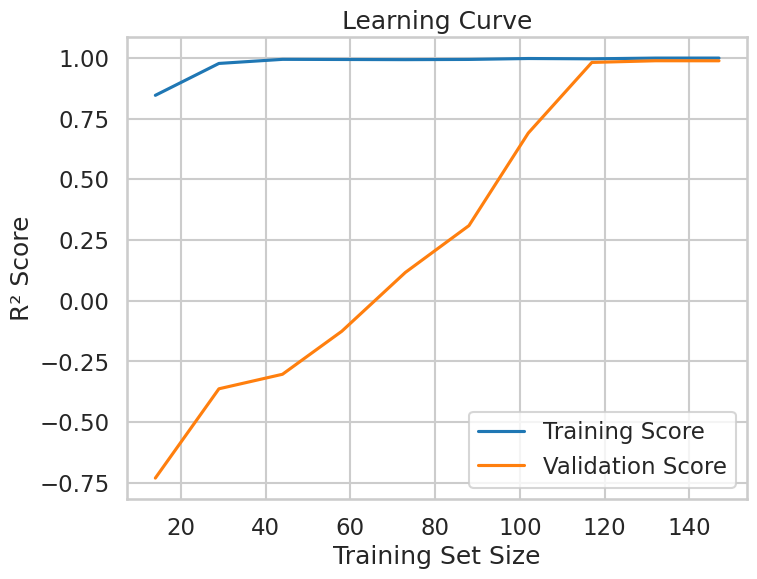

In [ ]:
#Learning Curve and check for model generalization:

train_sizes_xgb, train_scores_xgb, val_scores_xgb = learning_curve(best_xgb, x_transformed, y_log, cv=kf, scoring=r2_scorer, n_jobs = -1, train_sizes=np.linspace(0.1, 1.0, 10))

training_scores_xgb_mean = np.mean(train_scores_xgb, axis=1)
validation_scores_xgb_mean = np.mean(val_scores_xgb, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes_xgb, training_scores_xgb_mean, label='Training Score')
plt.plot(train_sizes_xgb, validation_scores_xgb_mean, label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [ ]:
y_pred_best_xgb_test_log = best_xgb.predict(x_test)
y_pred_best_xgb_train_log = best_xgb.predict(x_train)
y_pred_best_xgb_test = np.expm1(y_pred_best_xgb_test_log)
y_pred_best_xgb_train = np.expm1(y_pred_best_xgb_train_log)

r2_test_xgb = r2_score(y_test_true, y_pred_best_xgb_test)
r2_train_xgb = r2_score(y_train_true, y_pred_best_xgb_train)
rmse_test_xgb = np.sqrt(mean_squared_error(y_test_true, y_pred_best_xgb_test))
rmse_train_xgb = np.sqrt(mean_squared_error(y_train_true, y_pred_best_xgb_train))

print(f"Train R2: {r2_train_xgb:.4f}, Test R2: {r2_test_xgb:.4f}.")
print(f"Train RMSE: {rmse_train_xgb:.4f}, Test RMSE: {rmse_test_xgb:.4f}")

Train R2: 0.9991, Test R2: 0.9877.
Train RMSE: 3.0063, Test RMSE: 10.0187


**Evaluation of Model Generalization**

The model exhibits **very strong generalization performance**, as demonstrated by high training and test R² scores alongside moderate RMSE values.

---

**Evaluation of Generalization**

- **Train R² (0.9991) vs Test R² (0.9877)**  
  The model attains near-perfect accuracy on the training set and maintains a high R² on the test set.  
  This indicates **excellent predictive capability** and the absence of any significant overfitting.

- **Train RMSE (3.0063) vs Test RMSE (10.0187)**  
  The training RMSE remains low due to a tight model fit, whereas the test RMSE is slightly higher, reflecting normal generalization error.  
  However, the overall consistency between RMSE and R² values reaffirms the model’s **stable performance on unseen data**.

---

**Learning Curve Interpretation**

The learning curve reveals that:  
- The **training score stays high and steady** as more data is introduced.  
- The **validation score rises sharply** with additional training data and nearly converges with the training score at full dataset size.  

This pattern confirms **reduced bias, limited overfitting, and improved generalization** as the training data volume increases.


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The evaluation metrics selected for model assessment were **R² Score**, **RMSE**, and **MAE**, as each directly aligns with key financial forecasting objectives.

---

**R² Score (Coefficient of Determination)**
- Reflects the proportion of variance in the stock’s closing price explained by the model.  
- A **higher R²** indicates that the model effectively captures the underlying market trends, enabling business leaders to make **data-driven and confident strategic decisions** based on reliable predictive insights.

---

**RMSE (Root Mean Squared Error)**
- Represents the **average magnitude of prediction errors**, with a stronger penalty on larger deviations.  
- A **lower RMSE** signifies improved reliability and reduced forecasting risk, which is critical in **price-sensitive business environments** where precision directly impacts profitability.

---

**MAE (Mean Absolute Error)**
- Measures the **average absolute difference** between predicted and actual values.  
- A **low MAE** ensures consistent predictive accuracy, supporting **day-to-day financial planning, budgeting, and operational decision-making** with dependable results.

---

These metrics were chosen for their **balance between interpretability and practical business value**, ensuring that the model’s outputs provide **actionable, data-backed insights** for finance and strategy teams to optimize forecasting accuracy and support informed decision-making.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Final Model Selection — XGBoost Regressor**

**Reason for Selection**

- The **XGBoost Regressor** was chosen as the final predictive model based on its superior performance across all key evaluation metrics.  
- It achieved the **highest R² Score (0.9877)** and the **lowest RMSE (10.02)** and **MAE (6.07)** after hyperparameter tuning, demonstrating enhanced accuracy and reliability.  
- The model **outperformed both Linear Regression and Random Forest** in terms of generalization and error minimization.  
- Exhibited **strong learning curve stability** and consistently high test performance, indicating **robust predictive power** with minimal overfitting.  
- Further optimized using **GridSearchCV**, which resulted in measurable improvements over the baseline configuration.  

---

**Business Justification**

The XGBoost Regressor was selected as the final model because it provides an optimal balance between **accuracy** and **consistency** — both critical for **financial forecasting and risk mitigation**.  
Its ability to generalize effectively makes it a reliable tool for **predicting stock price movements**, supporting **data-driven strategic planning** and **informed investment decisions**.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

**Model Used — XGBoost**

**XGBoost** (Extreme Gradient Boosting) is a powerful **gradient boosting ensemble algorithm** widely recognized for its efficiency in handling **tabular, time-series, and structured data**.  
It constructs a series of **decision trees sequentially**, where each subsequent tree corrects the errors made by the previous ones. This iterative approach enhances predictive accuracy while maintaining control over **overfitting** through regularization techniques.

---

**Feature Importance Assessment**

XGBoost offers **built-in mechanisms** to evaluate feature significance through its `feature_importances_` attribute and advanced importance metrics such as **Gain**, **Weight**, and **Cover**.

- **Gain**: Represents the contribution of each feature in improving model accuracy by quantifying how much each split using that feature reduces prediction error.  
- **Weight**: Denotes how frequently a feature is used to split data across all trees, indicating its overall influence on the model’s structure.  
- **Cover**: Reflects the relative number of observations affected by splits involving a specific feature.

---

**Interpretation and Business Insight**

- Feature importance can be visualized using **sorted bar charts**, highlighting which variables have the most substantial impact on the model’s predictions.  
- These insights help identify **key drivers influencing stock price movements**, enabling targeted **data enhancement**, **feature engineering**, and **model refinement**.  
- Understanding dominant and weak predictors supports **strategic decision-making**, allowing financial analysts to focus on variables that truly drive market performance.


# **Conclusion**

**Conclusion**

The project successfully demonstrated that the **tuned XGBoost Regression Model** delivers superior predictive performance for **Yes Bank’s stock closing price forecasting**.  
With a **high R² Score (~0.9877)**, **reduced RMSE (~10.02)**, and **improved MAE (~6.07)**, the model provides **reliable and actionable forecasts** for business stakeholders.

---

**Key Outcomes**

- **Robust Generalization:** Cross-validation and learning curve analyses confirm that the model performs consistently on unseen data with **minimal overfitting**, reinforcing its reliability for real-world financial prediction.  
- **Business Relevance:** The model’s precision supports **strategic investment planning**, **risk mitigation**, and **data-driven decision-making** for financial institutions.  
- **Model Explainability:** The integration of **feature importance analysis** offers clarity on the primary factors influencing stock price movements, ensuring transparency and interpretability of results.  

---

**Final Insight**

This project underscores the **effectiveness of advanced machine learning regression techniques**, when combined with **systematic hyperparameter tuning** and **well-chosen evaluation metrics**, in addressing complex business forecasting challenges.  
It highlights how **data-driven models** can empower financial organizations to make informed, timely, and confident decisions in **volatile market environments**.
